In [36]:
import pandas as pd

In [37]:
# Después de haber limpiado el csv en Power Query. Separador ;
df_movies = pd.read_csv (r"C:\Users\NaiaJon\Documents\Naia\BootcampDataScience\Datos EDA\data_cine\tmdb_imdb_limpio.csv", sep=";")

In [38]:
#Que haya cargado todo bien después de la transformación
df_movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 436401 entries, 0 to 436400
Data columns (total 30 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   id                      436401 non-null  int64
 1   title                   436401 non-null  str  
 2   vote_average            436401 non-null  int64
 3   vote_count              436401 non-null  int64
 4   status                  436401 non-null  str  
 5   release_date            415063 non-null  str  
 6   revenue                 436401 non-null  int64
 7   runtime                 436401 non-null  int64
 8   adult                   436401 non-null  str  
 9   budget                  436401 non-null  int64
 10  imdb_id                 436401 non-null  str  
 11  original_language       436401 non-null  str  
 12  original_title          436401 non-null  str  
 13  popularity              436401 non-null  int64
 14  genre                   356728 non-null  str  
 15  production_

Nulos en género, director, país de producción... Me importan los de género porque es seguro que quiero analizar cómo impacta.

In [39]:
df = df_movies.dropna (subset="genre")

In [40]:
df.info()

<class 'pandas.DataFrame'>
Index: 356728 entries, 0 to 436400
Data columns (total 30 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   id                      356728 non-null  int64
 1   title                   356728 non-null  str  
 2   vote_average            356728 non-null  int64
 3   vote_count              356728 non-null  int64
 4   status                  356728 non-null  str  
 5   release_date            351950 non-null  str  
 6   revenue                 356728 non-null  int64
 7   runtime                 356728 non-null  int64
 8   adult                   356728 non-null  str  
 9   budget                  356728 non-null  int64
 10  imdb_id                 356728 non-null  str  
 11  original_language       356728 non-null  str  
 12  original_title          356728 non-null  str  
 13  popularity              356728 non-null  int64
 14  genre                   356728 non-null  str  
 15  production_count

In [41]:
#Revisar budget y revenue. Pueden no ser nulos pero ser cero es imposible
# Cuantos hay que tengan cero en presupuesto o recaudación?

print("Budget = 0:  ", (df["budget"] == 0).sum())
print("Revenue = 0: ", (df["revenue"] == 0).sum())
print("Alguno de los dos: ", ((df["budget"] == 0) | (df["revenue"] == 0)).sum())

#Pues menos mal que se me ha ocurrido mirarlo! :-(
# Me quedan 27300 pelis. Tampoco está mal

Budget = 0:   329340
Revenue = 0:  340610
Alguno de los dos:  346571


In [42]:
df = df [df ["budget"] != 0]

In [43]:
df.info()

<class 'pandas.DataFrame'>
Index: 27388 entries, 0 to 436390
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   id                      27388 non-null  int64
 1   title                   27388 non-null  str  
 2   vote_average            27388 non-null  int64
 3   vote_count              27388 non-null  int64
 4   status                  27388 non-null  str  
 5   release_date            26925 non-null  str  
 6   revenue                 27388 non-null  int64
 7   runtime                 27388 non-null  int64
 8   adult                   27388 non-null  str  
 9   budget                  27388 non-null  int64
 10  imdb_id                 27388 non-null  str  
 11  original_language       27388 non-null  str  
 12  original_title          27388 non-null  str  
 13  popularity              27388 non-null  int64
 14  genre                   27388 non-null  str  
 15  production_countries.1  23969 non-

In [44]:
print("Revenue = 0: ", (df["revenue"] == 0).sum())

Revenue = 0:  17231


In [45]:
# Quitar los que no tienen datos de recaudación
df = df [df ["revenue"] != 0]

In [46]:
df.info()

<class 'pandas.DataFrame'>
Index: 10157 entries, 0 to 436232
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   id                      10157 non-null  int64
 1   title                   10157 non-null  str  
 2   vote_average            10157 non-null  int64
 3   vote_count              10157 non-null  int64
 4   status                  10157 non-null  str  
 5   release_date            10123 non-null  str  
 6   revenue                 10157 non-null  int64
 7   runtime                 10157 non-null  int64
 8   adult                   10157 non-null  str  
 9   budget                  10157 non-null  int64
 10  imdb_id                 10157 non-null  str  
 11  original_language       10157 non-null  str  
 12  original_title          10157 non-null  str  
 13  popularity              10157 non-null  int64
 14  genre                   10157 non-null  str  
 15  production_countries.1  9867 non-n

In [47]:
print(df["release_date"].min())
print(df["release_date"].max())

01/01/1938
31/12/2019


De la base de datos de Mojo tiene que haber datos de presupuesto y recaudación. Intentar hacer merge?


In [48]:
import matplotlib.pyplot as plt
import seaborn as sns


C:\Users\NaiaJon\AppData\Local\Temp\ipykernel_15580\2182353626.py:3: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['year'] = pd.to_datetime (df['release_date']).dt.year


<Axes: xlabel='year'>

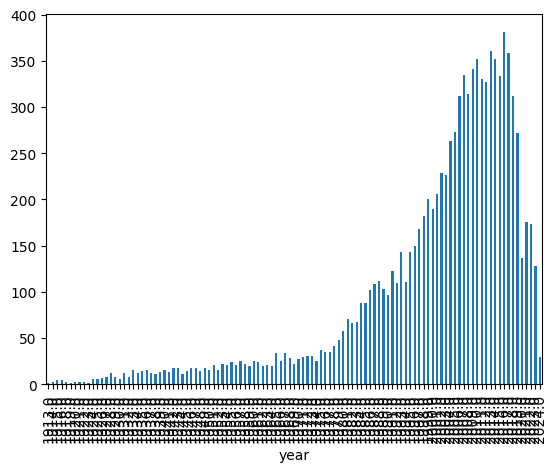

In [49]:
# `Voy a ver cómo se distribuyen en el tiempo esas películas
# Me voy a crear una columna año
df['year'] = pd.to_datetime (df['release_date']).dt.year
df['year'].value_counts().sort_index().plot(kind='bar')



<Axes: xlabel='year'>

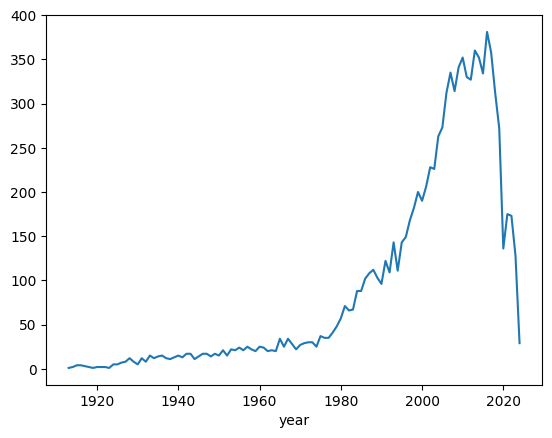

In [50]:
df['year'].value_counts().sort_index().plot(kind='line')

In [51]:
#Intentando hacer un gráfico con seaborn parece que me daba que había errores en year
df['year'].isnull().sum()

np.int64(34)

In [52]:
df['year'].max()

np.float64(2024.0)

In [53]:
df[(df['year'] >= 1980) & (df['year'] <= 2019)].info()

<class 'pandas.DataFrame'>
Index: 8351 entries, 0 to 431842
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      8351 non-null   int64  
 1   title                   8351 non-null   str    
 2   vote_average            8351 non-null   int64  
 3   vote_count              8351 non-null   int64  
 4   status                  8351 non-null   str    
 5   release_date            8351 non-null   str    
 6   revenue                 8351 non-null   int64  
 7   runtime                 8351 non-null   int64  
 8   adult                   8351 non-null   str    
 9   budget                  8351 non-null   int64  
 10  imdb_id                 8351 non-null   str    
 11  original_language       8351 non-null   str    
 12  original_title          8351 non-null   str    
 13  popularity              8351 non-null   int64  
 14  genre                   8351 non-null   str    
 15  p

In [54]:
# Antes de 1980 hay pocos datos que creo que alterarían el análisis y después de 2019 parte por la cercanía 
# parte por el COVID (entiendo) también hay pocos datos así que acoto la temporalidad (muy a mi pesar) a 
# 1980 - 2019. Me quedan 8300 valores que no está mal.
df_acotado = df[(df['year'] >= 1980) & (df['year'] <= 2019)]

#parece que ya no hay nulos en year
df_acotado ['year'].isnull().sum()

np.int64(0)

In [55]:
# Ultimos pasos para preparar el dataframe:
# 1- Valorar si (y cómo incluir los premios)
# 2 - Hay suficiente representación de pelis españolas para hacer tb un análisis propio?
# 3 - Bonus: Premios Vs edad. Sería otro dataframe así que lo dejo por si me queda tiempo

In [56]:
oscars = pd.read_csv (r"C:\Users\NaiaJon\Documents\Naia\BootcampDataScience\Datos EDA\data_cine\Oscar_Awards.csv", sep="\t")
print(oscars.shape)
oscars.tail()

(12014, 16)


,Ceremony,Year,Class,CanonicalCategory,Category,NomId,Film,FilmId,Name,Nominees,NomineeIds,Winner,Detail,Note,Citation,MultifilmNomination
12009,97,2024,SciTech,SCIENTIFIC AND TECHNICAL AWARD (Technical Achi...,SCIENTIFIC AND TECHNICAL AWARD (Technical Achi...,NaN,NaN,NaN,NaN,"Dustin Brooks, Colin Decker",NaN,True,NaN,Fire for Hire's gel first publicly demonstrate...,To DUSTIN BROOKS and COLIN DECKER for the deve...,NaN
12010,97,2024,SciTech,SCIENTIFIC AND TECHNICAL AWARD (Technical Achi...,SCIENTIFIC AND TECHNICAL AWARD (Technical Achi...,NaN,NaN,NaN,NaN,"Attila T. Áfra, Timo Aila",NaN,True,NaN,Open Image Denoise is an open-source library t...,To ATTILA T. ÁFRA for the creation of Intel Op...,NaN
12011,97,2024,SciTech,SCIENTIFIC AND TECHNICAL AWARD (Technical Achi...,SCIENTIFIC AND TECHNICAL AWARD (Technical Achi...,NaN,NaN,NaN,NaN,Mark Noel,NaN,True,NaN,The NACMO series of modular motion bases enabl...,To MARK NOEL for adapting and enhancing the sa...,NaN
12012,97,2024,SciTech,SCIENTIFIC AND TECHNICAL AWARD (Technical Achi...,SCIENTIFIC AND TECHNICAL AWARD (Technical Achi...,NaN,NaN,NaN,NaN,"Su Tie, Bei Shimen, Zhao Yanchong",NaN,True,NaN,Utilizing three-axis stabilization through mul...,To SU TIE for the development of the sensor an...,NaN
12013,97,2024,SciTech,SCIENTIFIC AND TECHNICAL AWARD (Technical Achi...,SCIENTIFIC AND TECHNICAL AWARD (Technical Achi...,NaN,NaN,NaN,NaN,"Tabb Firchau, John Ellison, Steve Webb, David ...",NaN,True,NaN,Freefly Systems' introduction of handheld stab...,To TABB FIRCHAU for the conception and develop...,NaN


In [57]:
# Habría que contabilizar por filmId pero ya veo que hay NaNs en ese campo
oscars ['FilmId'].isnull().sum()


np.int64(1261)

In [58]:
#Investigar si son relevantes, si son de pelis antiguas que ya voy a descartar o de categorías como documentales
# etc puedo pasar sin ellos

nulos = oscars[oscars ['FilmId'].isnull()]
nulos.info()

<class 'pandas.DataFrame'>
Index: 1261 entries, 22 to 12013
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Ceremony             1261 non-null   int64 
 1   Year                 1261 non-null   str   
 2   Class                1261 non-null   str   
 3   CanonicalCategory    1261 non-null   str   
 4   Category             1261 non-null   str   
 5   NomId                729 non-null    str   
 6   Film                 0 non-null      str   
 7   FilmId               0 non-null      str   
 8   Name                 121 non-null    str   
 9   Nominees             1260 non-null   str   
 10  NomineeIds           733 non-null    str   
 11  Winner               1235 non-null   object
 12  Detail               810 non-null    str   
 13  Note                 371 non-null    str   
 14  Citation             1140 non-null   str   
 15  MultifilmNomination  0 non-null      object
dtypes: int64(1), object(

In [59]:
#Año
nulos['Year'].describe()

count     1261
unique      95
top       1998
freq        38
Name: Year, dtype: object

In [60]:
nulos['Category'].value_counts()

Category
SCIENTIFIC AND TECHNICAL AWARD (Technical Achievement Award)         254
SCIENTIFIC OR TECHNICAL AWARD (Class III)                            180
SCIENTIFIC AND TECHNICAL AWARD (Scientific and Engineering Award)    170
HONORARY AWARD                                                       128
SCIENTIFIC OR TECHNICAL AWARD (Class II)                              91
SCIENTIFIC OR TECHNICAL AWARD (Technical Achievement Award)           89
SCIENTIFIC OR TECHNICAL AWARD (Scientific and Engineering Award)      67
IRVING G. THALBERG MEMORIAL AWARD                                     46
JEAN HERSHOLT HUMANITARIAN AWARD                                      45
SPECIAL AWARD                                                         33
GORDON E. SAWYER AWARD                                                27
SCIENTIFIC AND TECHNICAL AWARD (Academy Award of Merit)               21
JOHN A. BONNER MEDAL OF COMMENDATION                                  20
SCIENTIFIC OR TECHNICAL AWARD (Class I)   

In [61]:
#La mayoría son honoríficos o a categorías técnicas. Podríamos pasar de ellos. Voy a ver cuántos me quedan
# acotando a los años del estudio
# Errores: el año estaba en string y además hay entradas que eran del tipo 1927/1928
nulos ['Year'] = nulos['Year'].str[:4].astype (int)


In [62]:

nulos [(nulos['Year']>=1980) & (nulos['Year']<=2020)].info() #los premios se dan con un año de retraso



<class 'pandas.DataFrame'>
Index: 726 entries, 6272 to 11478
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Ceremony             726 non-null    int64 
 1   Year                 726 non-null    int64 
 2   Class                726 non-null    str   
 3   CanonicalCategory    726 non-null    str   
 4   Category             726 non-null    str   
 5   NomId                437 non-null    str   
 6   Film                 0 non-null      str   
 7   FilmId               0 non-null      str   
 8   Name                 35 non-null     str   
 9   Nominees             725 non-null    str   
 10  NomineeIds           437 non-null    str   
 11  Winner               726 non-null    object
 12  Detail               501 non-null    str   
 13  Note                 313 non-null    str   
 14  Citation             691 non-null    str   
 15  MultifilmNomination  0 non-null      object
dtypes: int64(2), object

In [63]:
#Hay 726 nulos en el rango a estudiar

In [64]:
nulos [(nulos['Year']>=1980) & (nulos['Year']<=2020)]["Category"].value_counts()

Category
SCIENTIFIC AND TECHNICAL AWARD (Technical Achievement Award)         232
SCIENTIFIC AND TECHNICAL AWARD (Scientific and Engineering Award)    155
SCIENTIFIC OR TECHNICAL AWARD (Technical Achievement Award)           75
HONORARY AWARD                                                        67
SCIENTIFIC OR TECHNICAL AWARD (Scientific and Engineering Award)      65
GORDON E. SAWYER AWARD                                                26
JEAN HERSHOLT HUMANITARIAN AWARD                                      22
SCIENTIFIC AND TECHNICAL AWARD (Academy Award of Merit)               21
JOHN A. BONNER MEDAL OF COMMENDATION                                  20
IRVING G. THALBERG MEMORIAL AWARD                                     13
AWARD OF COMMENDATION                                                 12
MEDAL OF COMMENDATION                                                 10
SCIENTIFIC OR TECHNICAL AWARD (Academy Award of Merit)                 7
SCIENTIFIC AND TECHNICAL AWARD (Special Aw

Son premios técnicos y honoríficos. Por eso no tienen FilmId la mayoría. Los eliminamos

In [65]:
oscars ['Year'] = oscars ['Year'].str[:4].astype (int)


In [66]:
#Me quedo con los años
oscars_acotado = oscars [(oscars ['Year'] >= 1980)&(oscars ['Year'] <= 2020)]

In [67]:
#Quito los premios sin FIlmId
oscars_acotado = oscars_acotado[oscars_acotado['FilmId'].notnull()]

In [68]:
oscars_acotado.info()

<class 'pandas.DataFrame'>
Index: 4578 entries, 6175 to 11476
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Ceremony             4578 non-null   int64 
 1   Year                 4578 non-null   int64 
 2   Class                4578 non-null   str   
 3   CanonicalCategory    4578 non-null   str   
 4   Category             4578 non-null   str   
 5   NomId                4578 non-null   str   
 6   Film                 4578 non-null   str   
 7   FilmId               4578 non-null   str   
 8   Name                 4575 non-null   str   
 9   Nominees             4373 non-null   str   
 10  NomineeIds           4373 non-null   str   
 11  Winner               972 non-null    object
 12  Detail               1015 non-null   str   
 13  Note                 11 non-null     str   
 14  Citation             3 non-null      str   
 15  MultifilmNomination  0 non-null      object
dtypes: int64(2), objec

In [69]:
type (oscars_acotado)

pandas.DataFrame

In [70]:
#Necesito crearme un dataframe con:
# Film Id
# Número nominaciones
# Número de oscars
# en winner está como null los no ganadores: sustituir por False
# Y luego hacer un merge al dataframe de trabajo

oscars_acotado = oscars_acotado [['Year','FilmId','Category','Winner']]

In [71]:
oscars_acotado.info()

<class 'pandas.DataFrame'>
Index: 4578 entries, 6175 to 11476
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Year      4578 non-null   int64 
 1   FilmId    4578 non-null   str   
 2   Category  4578 non-null   str   
 3   Winner    972 non-null    object
dtypes: int64(1), object(1), str(2)
memory usage: 178.8+ KB


In [72]:
oscars_acotado.fillna(False, inplace=True)

,Year,FilmId,Category,Winner
6175,1980,tt0081398,ACTOR IN A LEADING ROLE,True
6176,1980,tt0079239,ACTOR IN A LEADING ROLE,False
6177,1980,tt0080678,ACTOR IN A LEADING ROLE,False
6178,1980,tt0081656,ACTOR IN A LEADING ROLE,False
6179,1980,tt0081568,ACTOR IN A LEADING ROLE,False
...,...,...,...,...
11472,2020,tt9784798,WRITING (Original Screenplay),False
11473,2020,tt10633456,WRITING (Original Screenplay),False
11474,2020,tt9620292,WRITING (Original Screenplay),True
11475,2020,tt5363618,WRITING (Original Screenplay),False


In [73]:
oscars_acotado.info()

<class 'pandas.DataFrame'>
Index: 4578 entries, 6175 to 11476
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Year      4578 non-null   int64 
 1   FilmId    4578 non-null   str   
 2   Category  4578 non-null   str   
 3   Winner    4578 non-null   object
dtypes: int64(1), object(1), str(2)
memory usage: 178.8+ KB


In [74]:
#ASIGNAR! SI no no hace nada!!!
oscars_acotado['Winner'] = oscars_acotado['Winner'].astype(int)

In [75]:
# Contar los nominados (filas) y premios (Trues)
awards_and_nominees = oscars_acotado.groupby('FilmId')['Winner'].aggregate(['count', 'sum']).rename(columns={'count': 'nominees', 'sum': 'awards'}).reset_index()

In [76]:
awards_and_nominees.head()

,FilmId,nominees,awards
0,tt0035423,1,0
1,tt0078868,1,0
2,tt0079239,2,0
3,tt0079579,1,1
4,tt0079596,1,0


In [77]:
awards_and_nominees ['nominees'].max()

np.int64(14)

In [78]:
awards_and_nominees.info()

<class 'pandas.DataFrame'>
RangeIndex: 2206 entries, 0 to 2205
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   FilmId    2206 non-null   str  
 1   nominees  2206 non-null   int64
 2   awards    2206 non-null   int64
dtypes: int64(2), str(1)
memory usage: 51.8 KB


In [79]:
df_acotado.info()

<class 'pandas.DataFrame'>
Index: 8351 entries, 0 to 431842
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      8351 non-null   int64  
 1   title                   8351 non-null   str    
 2   vote_average            8351 non-null   int64  
 3   vote_count              8351 non-null   int64  
 4   status                  8351 non-null   str    
 5   release_date            8351 non-null   str    
 6   revenue                 8351 non-null   int64  
 7   runtime                 8351 non-null   int64  
 8   adult                   8351 non-null   str    
 9   budget                  8351 non-null   int64  
 10  imdb_id                 8351 non-null   str    
 11  original_language       8351 non-null   str    
 12  original_title          8351 non-null   str    
 13  popularity              8351 non-null   int64  
 14  genre                   8351 non-null   str    
 15  p

In [80]:
awards_and_nominees.rename (columns={"FilmId": "imdb_id"}, inplace=True)

In [81]:
#Agregar estas filas al dataset de trabajo. Mantener todo el dataset y que añada los premios/nominaciones
#donde coincida

df_pelisfinal = df_acotado.merge (awards_and_nominees, how='left', on='imdb_id')

In [82]:
df_pelisfinal.info()

<class 'pandas.DataFrame'>
RangeIndex: 8351 entries, 0 to 8350
Data columns (total 33 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      8351 non-null   int64  
 1   title                   8351 non-null   str    
 2   vote_average            8351 non-null   int64  
 3   vote_count              8351 non-null   int64  
 4   status                  8351 non-null   str    
 5   release_date            8351 non-null   str    
 6   revenue                 8351 non-null   int64  
 7   runtime                 8351 non-null   int64  
 8   adult                   8351 non-null   str    
 9   budget                  8351 non-null   int64  
 10  imdb_id                 8351 non-null   str    
 11  original_language       8351 non-null   str    
 12  original_title          8351 non-null   str    
 13  popularity              8351 non-null   int64  
 14  genre                   8351 non-null   str    
 15

In [83]:
#Por qué sólo 1095?? Qué pasa con el resto?

In [84]:
awards_and_nominees ['imdb_id'].sample (20)

1930    tt2976354
418     tt0095497
1347    tt0418689
1967    tt3449252
569     tt0101969
935     tt0120751
2084    tt5613056
835     tt0116695
1349    tt0419279
1744    tt1613750
326     tt0091886
431     tt0095953
1920    tt2852406
294     tt0090831
278     tt0090223
1193    tt0308644
1366    tt0433383
1592    tt1135503
1608    tt1164999
1125    tt0250797
Name: imdb_id, dtype: str

In [85]:
df_acotado ['imdb_id'].sample (20)

43495     tt6221000
7076      tt4129870
267364    tt1475099
4272      tt9172422
105362    tt5735210
6747      tt0093512
1818      tt0312004
704       tt1277953
3581      tt1034331
14054     tt0470765
7566      tt0486674
142363    tt1216640
3023      tt3881784
11990     tt0101453
15258     tt1242599
3389      tt0327162
1577      tt0838283
35074     tt4497686
90711     tt2244376
7068      tt0119215
Name: imdb_id, dtype: str

In [86]:
no_estan = awards_and_nominees[~awards_and_nominees['imdb_id'].isin(df_acotado['imdb_id'])]
no_estan ['imdb_id'].sample (20)

1342    tt0414469
2084    tt5613056
876     tt0118566
110     tt0084023
1749    tt1620446
41      tt0081150
206     tt0087468
111     tt0084118
993     tt0150915
1896    tt2486682
1666    tt1333634
1967    tt3449252
164     tt0086067
384     tt0094119
569     tt0101969
30      tt0080798
315     tt0091538
274     tt0090043
501     tt0099191
2026    tt4284010
Name: imdb_id, dtype: str

In [87]:
# Parece que les faltaban datos de presupuesto, recaudación o género. 
# Me quedo con las 1095 premiadas
# Reviso que los datos y tipos del dataset están correctos

In [88]:
df_pelisfinal ['awards'] = df_pelisfinal ['awards'].fillna (0)
df_pelisfinal ['nominees']= df_pelisfinal ['nominees'].fillna (0)

In [89]:
df_pelisfinal.info()

<class 'pandas.DataFrame'>
RangeIndex: 8351 entries, 0 to 8350
Data columns (total 33 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      8351 non-null   int64  
 1   title                   8351 non-null   str    
 2   vote_average            8351 non-null   int64  
 3   vote_count              8351 non-null   int64  
 4   status                  8351 non-null   str    
 5   release_date            8351 non-null   str    
 6   revenue                 8351 non-null   int64  
 7   runtime                 8351 non-null   int64  
 8   adult                   8351 non-null   str    
 9   budget                  8351 non-null   int64  
 10  imdb_id                 8351 non-null   str    
 11  original_language       8351 non-null   str    
 12  original_title          8351 non-null   str    
 13  popularity              8351 non-null   int64  
 14  genre                   8351 non-null   str    
 15

In [90]:
# Hay muchas columnas con info que no sé si voy a usar. Voy a quedarme con las principales
pelis_categorias_ppales = df_pelisfinal[list(df_pelisfinal.columns[:15]) + ['averageRating'] + list(df_pelisfinal.columns[-3:])]

In [91]:
pelis_categorias_ppales.info()

<class 'pandas.DataFrame'>
RangeIndex: 8351 entries, 0 to 8350
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8351 non-null   int64  
 1   title              8351 non-null   str    
 2   vote_average       8351 non-null   int64  
 3   vote_count         8351 non-null   int64  
 4   status             8351 non-null   str    
 5   release_date       8351 non-null   str    
 6   revenue            8351 non-null   int64  
 7   runtime            8351 non-null   int64  
 8   adult              8351 non-null   str    
 9   budget             8351 non-null   int64  
 10  imdb_id            8351 non-null   str    
 11  original_language  8351 non-null   str    
 12  original_title     8351 non-null   str    
 13  popularity         8351 non-null   int64  
 14  genre              8351 non-null   str    
 15  averageRating      8351 non-null   int64  
 16  year               8351 non-null   

In [92]:
pelis_categorias_ppales.sample(5)

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,budget,imdb_id,original_language,original_title,popularity,genre,averageRating,year,nominees,awards
7501,67238,Cavite,54,9,Released,12/03/2005,70,80,FALSO,7,tt0428303,en,Cavite,906,Thriller,60,2005.0,0.0,0.0
5404,535845,Brian Banks,7242,188,Released,09/08/2019,4300000,99,FALSO,10000000,tt3920820,en,Brian Banks,21565,Drama,72,2019.0,0.0,0.0
4379,13257,Mr. Woodcock,50,403,Released,14/09/2007,33683200,87,FALSO,22000000,tt0419984,en,Mr. Woodcock,9456,Comedy,52,2007.0,0.0,0.0
5866,27804,The Thing Called Love,6298,124,Released,27/08/1993,1029721,116,FALSO,14000000,tt0108327,en,The Thing Called Love,15074,Drama,64,1993.0,0.0,0.0
7021,81060,Happy,63,26,Released,27/01/2006,5800000,152,FALSO,2200000,tt0491775,te,హ్యాపీ,3641,Drama,71,2006.0,0.0,0.0


In [93]:
#Hay tres valores de popularidad. Unificar
pelis_categorias_ppales['vote_average'].describe()

count    8351.000000
mean     4397.906718
std      2980.318447
min         0.000000
25%       100.000000
50%      5901.000000
75%      6685.000000
max      8702.000000
Name: vote_average, dtype: float64

In [94]:
pelis_categorias_ppales ['popularity'].describe()

count      8351.000000
mean      14937.751766
std       16107.962556
min           0.000000
25%        4306.000000
50%       12146.000000
75%       19348.500000
max      357731.000000
Name: popularity, dtype: float64

In [95]:
pelis_categorias_ppales ['averageRating'].describe()

count    8351.000000
mean       63.065621
std        11.229303
min        11.000000
25%        57.000000
50%        64.000000
75%        71.000000
max       100.000000
Name: averageRating, dtype: float64

In [96]:
df_pelisfinal['vote_average'].sample(10)

4876    6863
5892    7079
7546      60
8292       0
1345    5905
6549      62
4515    6173
7019    6212
2713    7366
2436    6712
Name: vote_average, dtype: int64

In [97]:
# Me quedo sólo con average_rating. Las otras dos o miden otra cosa (parece que popularity mide búsquedas o algo
# así y no valoraciones). Vote average creo que se ha corrompido en algún punto. Tiene una distribución muy
# rara.

In [98]:
pelis_categorias_ppales=pelis_categorias_ppales.drop (columns=["popularity", "vote_average"])

In [99]:
pelis_categorias_ppales=pelis_categorias_ppales.drop (columns=["vote_count"])

In [100]:
# Como valor comparativo es interesante ver el retorno de inversión: cuanto recaudan en relación a lo que cuestan
# Creo la columna ROI
pelis_categorias_ppales ['ROI'] = pelis_categorias_ppales ['revenue']/pelis_categorias_ppales['budget']

In [101]:
pelis_categorias_ppales.info()

<class 'pandas.DataFrame'>
RangeIndex: 8351 entries, 0 to 8350
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8351 non-null   int64  
 1   title              8351 non-null   str    
 2   status             8351 non-null   str    
 3   release_date       8351 non-null   str    
 4   revenue            8351 non-null   int64  
 5   runtime            8351 non-null   int64  
 6   adult              8351 non-null   str    
 7   budget             8351 non-null   int64  
 8   imdb_id            8351 non-null   str    
 9   original_language  8351 non-null   str    
 10  original_title     8351 non-null   str    
 11  genre              8351 non-null   str    
 12  averageRating      8351 non-null   int64  
 13  year               8351 non-null   float64
 14  nominees           8351 non-null   float64
 15  awards             8351 non-null   float64
 16  ROI                8351 non-null   

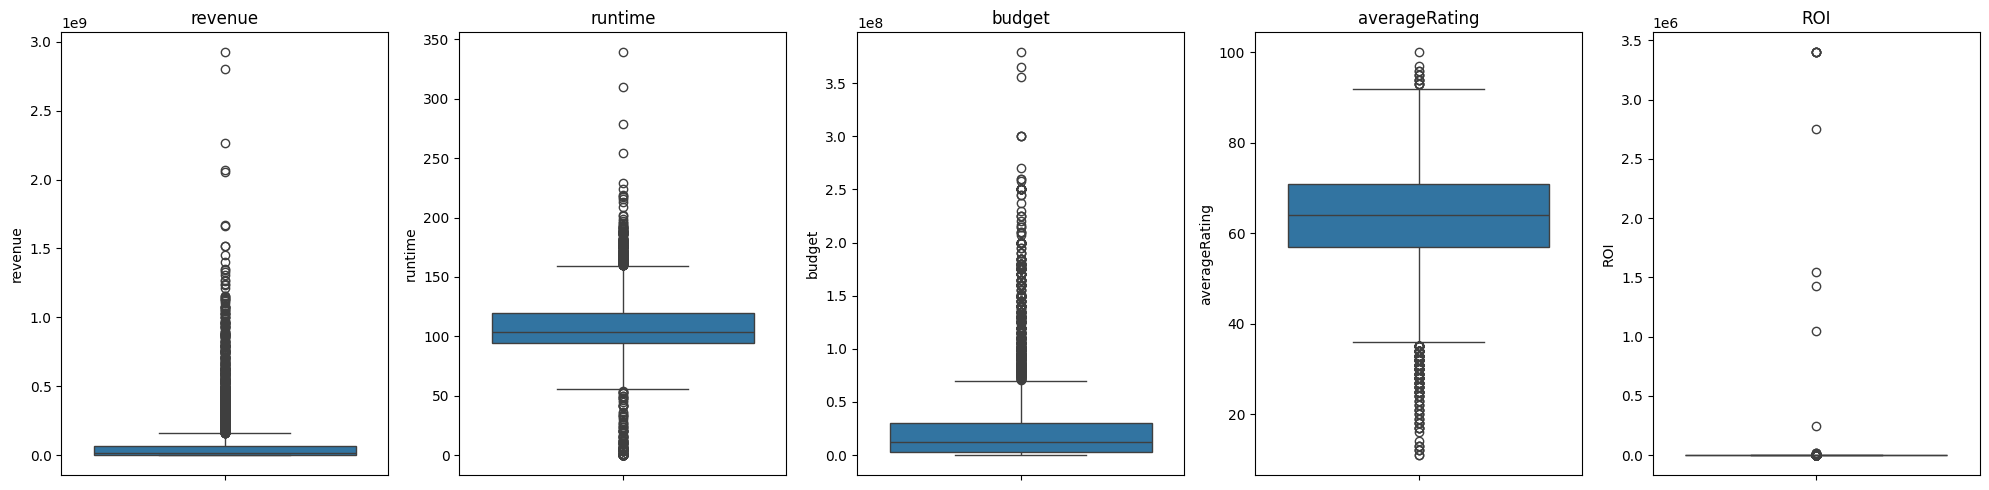

In [102]:
# Boxplots de las categorías numéricas para ver si hay cosas raras. Las pinto en plots distintos porque
# hay 

import matplotlib.pyplot as plt
cols = ["revenue", "runtime","budget","averageRating","ROI"]
fig, axes = plt.subplots(1, len(cols), figsize=(20, 5))
for i, col in enumerate(cols):
    sns.boxplot(data=pelis_categorias_ppales[col], ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

Hay cosas demasiado raras en revenue y budget. Parece que hay muchos valores muy bajos. Hay que determinar dónde limitamos para distinguir qué es un error de una peli de muy bajo presupuesto

In [103]:
print((pelis_categorias_ppales['budget'] < 1000).sum())
print((pelis_categorias_ppales['revenue'] < 1000).sum())

166
172


In [104]:
# Cuantas hay por debajo de 100000 dólares
print((pelis_categorias_ppales['budget'] < 100000).sum())

510


In [105]:
pelis_categorias_ppales[pelis_categorias_ppales['budget'] < 100000]['budget'].describe()

count      510.000000
mean     16670.243137
std      23115.135108
min          1.000000
25%        263.250000
50%       9150.000000
75%      20142.500000
max      96000.000000
Name: budget, dtype: float64

La mediana son 9150. Voy a quitar las de presupuesto menor de 10.000

In [106]:
pelis_categorias_ppales = pelis_categorias_ppales [pelis_categorias_ppales['budget']>=10000]

In [107]:
# Vamos a ver lo mismo con revenue
pelis_categorias_ppales[pelis_categorias_ppales['revenue'] < 10000]['revenue'].describe()

count     109.000000
mean     3496.899083
std      2974.010087
min         1.000000
25%       881.000000
50%      2970.000000
75%      5728.000000
max      9617.000000
Name: revenue, dtype: float64

In [108]:
pelis_categorias_ppales[pelis_categorias_ppales['revenue'] < 10000][['imdb_id','revenue']]

,imdb_id,revenue
3935,tt3177316,9318
3969,tt1519461,7556
4041,tt0154421,7235
4367,tt0120860,6374
4431,tt2383068,9221
...,...,...
8212,tt4232188,5000
8214,tt7616710,17
8229,tt5761968,5152
8284,tt6449580,2000


He ido a comprobar a Box Office Mojo. Por ejemplo los 9318 son correctos pero sólo está contando la recaudación doméstica. Igual es así para todas las pelis... 
https://www.boxofficemojo.com/title/tt3177316/?ref_=bo_se_r_1
He comprobado otro par alrededor de 5000 y los datos son correctos

In [109]:
pelis_categorias_ppales[pelis_categorias_ppales['revenue'] < 4000][['imdb_id','revenue']]

,imdb_id,revenue
4904,tt0953318,27
4969,tt0400426,743
4979,tt7869070,3153
5340,tt5096536,3176
5390,tt1867093,2521
...,...,...
8166,tt1578802,500
8190,tt8286772,2263
8214,tt7616710,17
8284,tt6449580,2000


Lo mismo. Hay algunas que o no tienen datos o son erróneos y otras que han cogido sólo la recaudación doméstica. Voy a quitar todas las de menos de 5000 dólares de recaudación

In [110]:
pelis_categorias_ppales = pelis_categorias_ppales [pelis_categorias_ppales['revenue']>=5000]

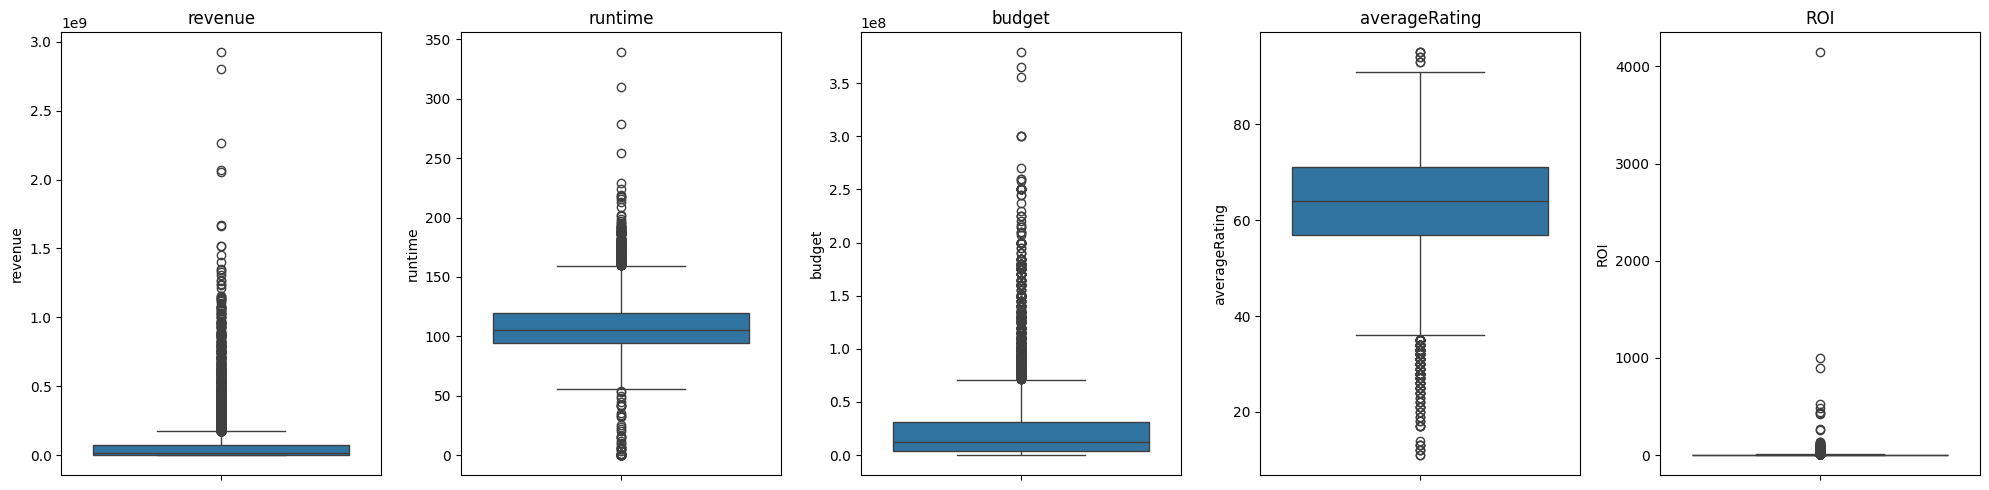

In [111]:
import matplotlib.pyplot as plt
cols = ["revenue", "runtime","budget","averageRating","ROI"]
fig, axes = plt.subplots(1, len(cols), figsize=(20, 5))
for i, col in enumerate(cols):
    sns.boxplot(data=pelis_categorias_ppales[col], ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

Ahora que tengo el dataset limpio para trabajar me lo voy a guardar en un csv para no tener que ejecutar todo lo anterior cada vez que empiezo a trabajar

In [112]:
pelis_categorias_ppales.to_csv ('data/pelis_ppal.csv', sep=';', index=False)

In [113]:
#Para ejecutar desde aquí
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [114]:
pelis = pd.read_csv ('data/pelis_ppal.csv', sep=';')

In [115]:
pelis ['original_language'].value_counts()

original_language
en    6079
hi     296
fr     226
ru     194
es     156
      ... 
mn       1
si       1
km       1
az       1
dv       1
Name: count, Length: 61, dtype: int64

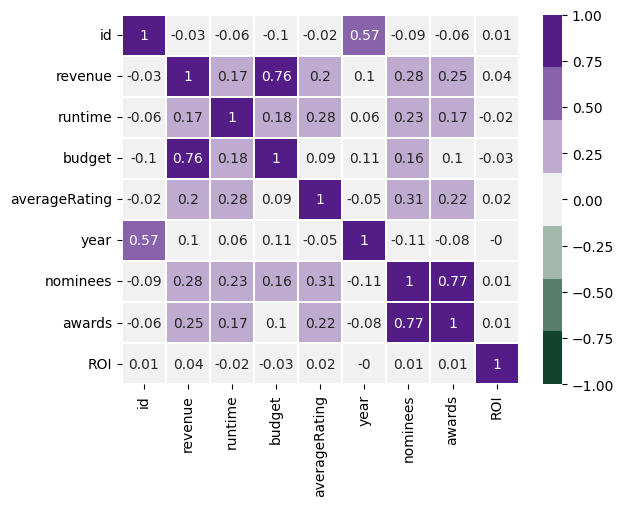

In [116]:
# En general, qué correlaciones entre datos hay?
sns.heatmap(pelis.select_dtypes(include='number').corr().round(2),
            vmin=-1,
            vmax=1,
            cmap=sns.diverging_palette(145, 280, s=85, l=25, n=7), #aquí ha fijado los parámetros de la escala de color para que sea apropiado para el heatmap
            linewidths=.1,
            annot=True);

budget-revenue (0.76): la correlación más clara: más presupuesto = más recaudación.
nominees-awards (0.77): más nominaciones = más premios (no aporta mucho, está claro que es imposible que te den premios si no te nominan)
averageRating-nominees (0.31): las películas mejor valoradas tienden a tener más nominaciones, aunque la correlación es moderada.
nominees-revenue (0.28) : las peliculas nominadas tienden a recaudar más. Es muy moderada
averageRating-runtime (0.28) y runtime-nominees (0.23): correlaciones débiles pero curiosas, las películas más largas tienden a nominarse y valorarse más.

<Axes: xlabel='budget', ylabel='revenue'>

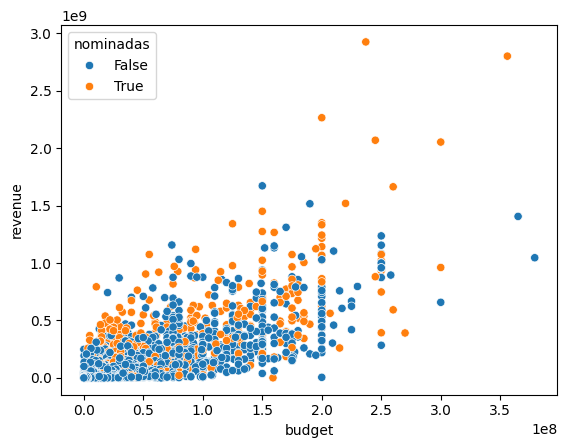

In [117]:
# -	¿Las películas con mayor presupuesto recaudan más?
pelis['nominadas'] = pelis['nominees'] > 0
sns.scatterplot(data=pelis, x='budget', y='revenue', hue='nominadas')

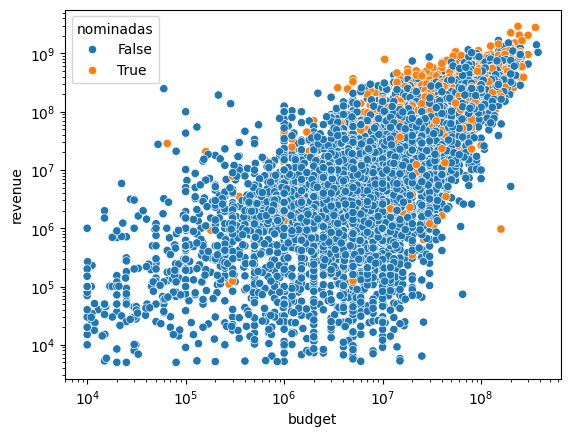

In [118]:
# -	¿Las de mayor presupuesto tienen más nominaciones?
#Añado una escala logarítmica para ver mejor los datos. Al haber tantos outliers de presupuesto/recaudación alta los puntos se concentran en la
# parte inferior izda y no se aprecia bien
sns.scatterplot(data=pelis, x='budget', y='revenue', hue='nominadas')
plt.xscale('log')
plt.yscale('log')

In [119]:
pelis['budget_M'] = pelis['budget'] / 1e6
pelis['revenue_M'] = pelis['revenue'] / 1e6

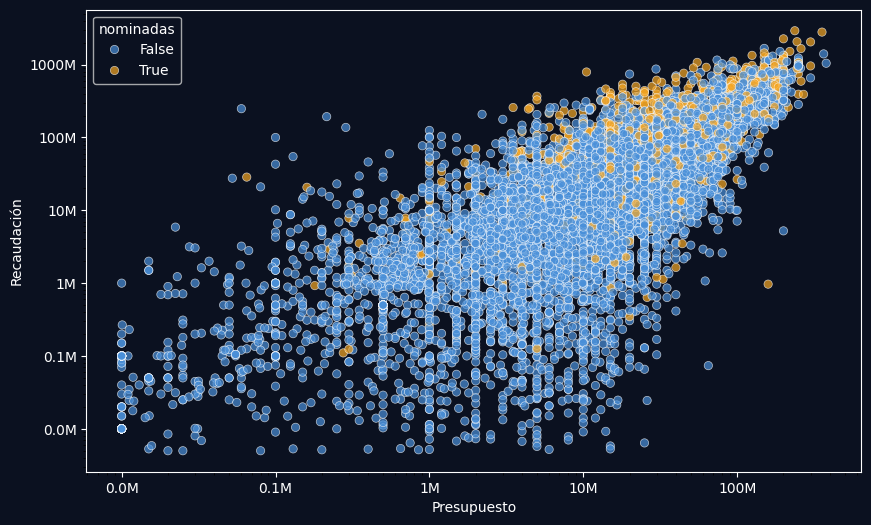

In [120]:
fig, ax = plt.subplots(figsize=(10, 6), facecolor='#0b1120')
ax.set_facecolor('#0b1120')

sns.scatterplot(data=pelis, x='budget_M', y='revenue_M', hue='nominadas',
                palette={False: '#4A90D9', True: '#F5A623'},
                alpha=0.7, ax=ax)

# Colores del texto y ejes en blanco para que se vean
ax.tick_params(colors='white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.title.set_color('white')
plt.setp(ax.spines.values(), color='white')
legend = ax.get_legend()
legend.get_frame().set_facecolor('#0b1120')
legend.get_title().set_color('white')
for text in legend.get_texts():
    text.set_color('white')
plt.xlabel('Presupuesto')
plt.ylabel('Recaudación')
#La escala logarítmica porque si no está aplanado
plt.xscale('log')
plt.yscale('log')

#Para que siga manteniendo la escala logarítmica en el eje pero las etiquetas muestren valores 
# comprensibles en millones de euros
from matplotlib.ticker import FuncFormatter
def formato_millones(x, _):
    if x >= 1000:
        return f'{x:.0f}M'
    elif x >= 1:
        return f'{x:.0f}M'
    else:
        return f'{x:.1f}M'
formatter = FuncFormatter(formato_millones)
ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)


In [121]:
#Parece que sí hay una correlación entre presupuesto y recaudación. 
# Se ve también que las nominaciones se concentran arriba a la derecha, es decir a tener mayor presupuesto y recaudación que las no-nominadas.
# Hay bastantes no nominadas con presupuesto alto, es decir, tener mucho presupuesto no garantiza una nominación.

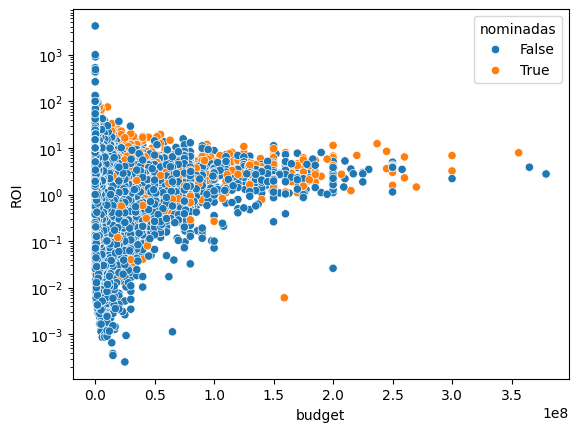

In [122]:
#Son más rentables?
pelis['nominadas'] = pelis['nominees'] > 0
sns.scatterplot(data=pelis, x='budget', y='ROI', hue='nominadas')
plt.yscale('log')

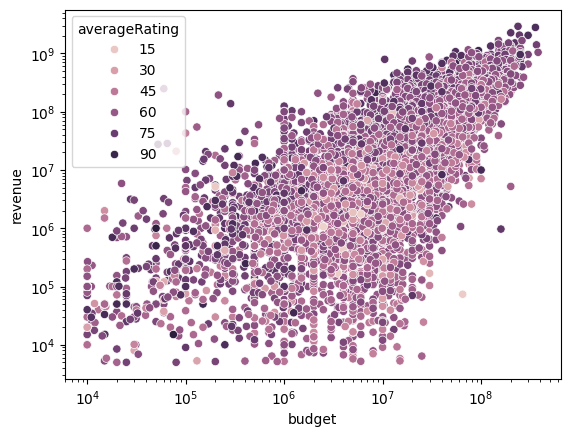

In [123]:
sns.scatterplot(data=pelis, x='budget', y='revenue', hue='averageRating')
plt.xscale('log')
plt.yscale('log')

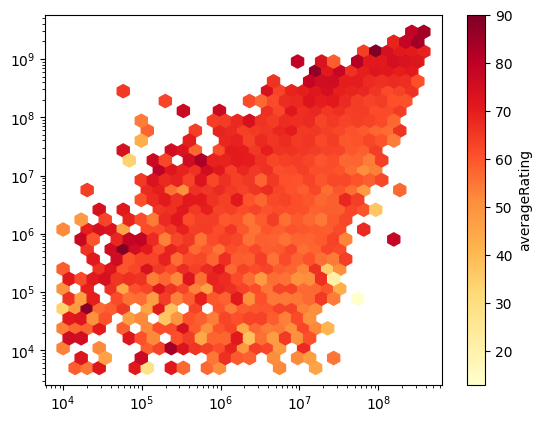

In [124]:
plt.hexbin(pelis['budget'], pelis['revenue'], C=pelis['averageRating'], 
           xscale='log', yscale='log', gridsize=30, cmap='YlOrRd')
plt.colorbar(label='averageRating')

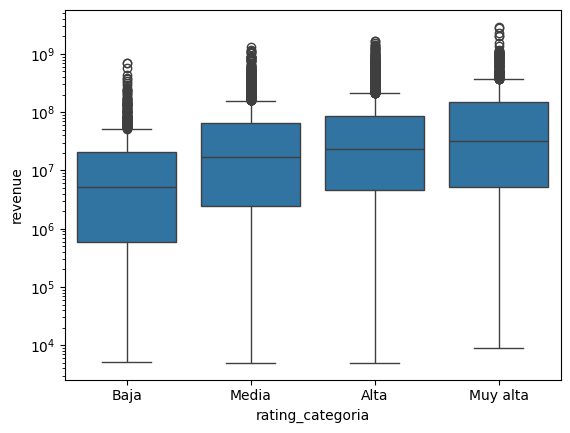

In [125]:
pelis['rating_categoria'] = pd.cut(pelis['averageRating'], 
                                    bins=[0, 50, 65, 75, 100], 
                                    labels=['Baja', 'Media', 'Alta', 'Muy alta'])

sns.boxplot(data=pelis, x='rating_categoria', y='revenue')
plt.yscale('log')

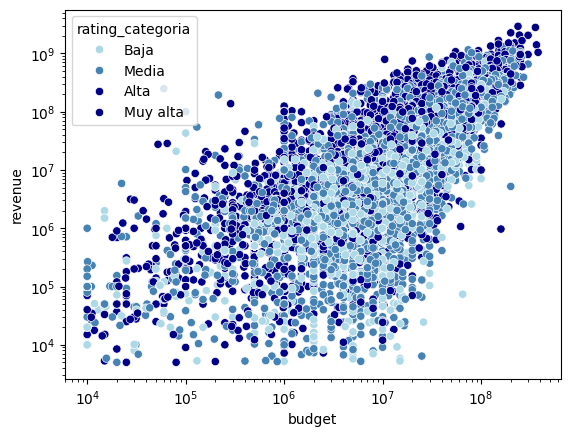

In [126]:
sns.scatterplot(data=pelis, x='budget', y='revenue', hue='rating_categoria', palette={'Baja': 'lightblue', 'Media': 'steelblue', 'Alta': 'darkblue', 'Muy alta': 'navy'})
plt.xscale('log')
plt.yscale('log')

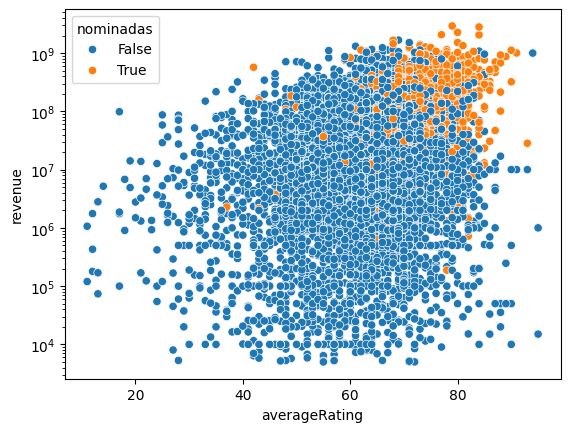

In [127]:
# -	¿Coinciden premios y público?
sns.scatterplot (data=pelis, x='averageRating', y='revenue', hue='nominadas')
plt.yscale('log')

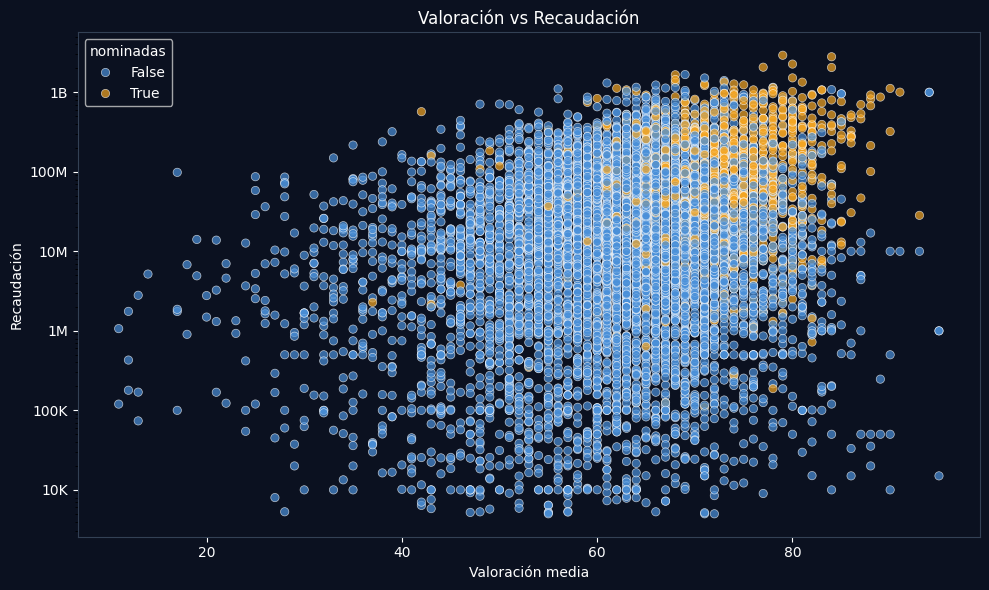

In [128]:
#Para ponerlo en la presentación:
fig, ax = plt.subplots(figsize=(10, 6), facecolor='#0b1120')
ax.set_facecolor('#0b1120')

sns.scatterplot(data=pelis, x='averageRating', y='revenue_M', hue='nominadas',
                palette={False: '#4A90D9', True: '#F5A623'},
                alpha=0.7, ax=ax)

plt.yscale('log')

ax.tick_params(colors='white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.title.set_color('white')
plt.setp(ax.spines.values(), color='#334155')

legend = ax.get_legend()
legend.get_frame().set_facecolor('#0b1120')
legend.get_title().set_color('white')
for text in legend.get_texts():
    text.set_color('white')

from matplotlib.ticker import FuncFormatter
def formatter(x, _):
    if x >= 1000:
        return f'{x/1000:.0f}B'
    elif x >= 1:
        return f'{x:.0f}M'
    else:
        return f'{x*1000:.0f}K'

ax.yaxis.set_major_formatter(FuncFormatter(formatter))
ax.set_xlabel('Valoración media', color='white')
ax.set_ylabel('Recaudación', color='white')
ax.set_title('Valoración vs Recaudación', color='white')

plt.tight_layout()
plt.show()

In [129]:
pelis.groupby('nominadas')['averageRating'].describe()

,count,mean,std,min,25%,50%,75%,max
nominadas,,,,,,,,
False,6930.0,61.496248,10.696676,11.0,56.0,63.0,69.0,95.0
True,1094.0,73.173675,6.616608,37.0,69.0,74.0,78.0,93.0


In [130]:
#Un p-value podría ser relevante? Revisar
from scipy import stats

nominadas = pelis[pelis['nominadas'] == True]['averageRating']
no_nominadas = pelis[pelis['nominadas'] == False]['averageRating']

stats.ttest_ind(nominadas, no_nominadas)

TtestResult(statistic=np.float64(35.063740837187154), pvalue=np.float64(9.883025004943831e-251), df=np.float64(8022.0))

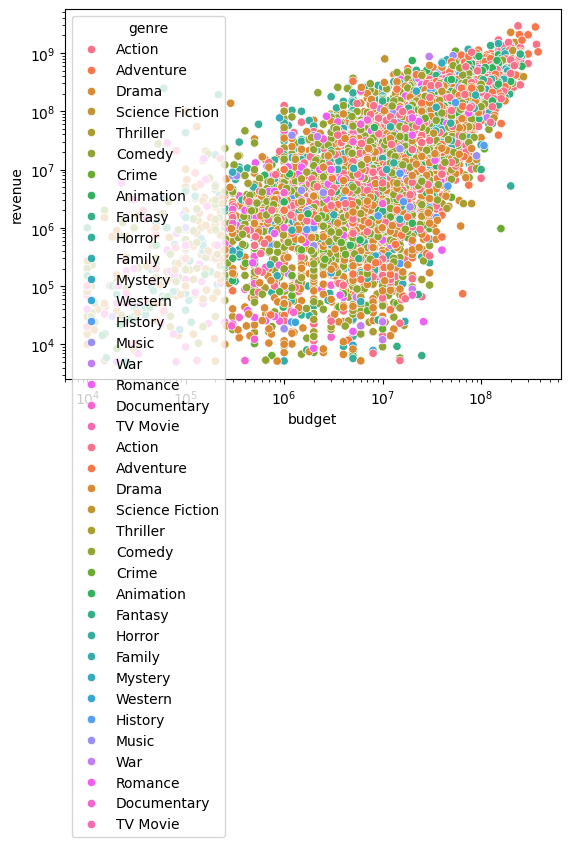

In [131]:
sns.scatterplot(data=pelis, x='budget', y='revenue', hue='genre')
sns.scatterplot(data=pelis, x='budget', y='revenue', hue='genre')
plt.xscale('log')
plt.yscale('log')

<Axes: xlabel='count', ylabel='genre'>

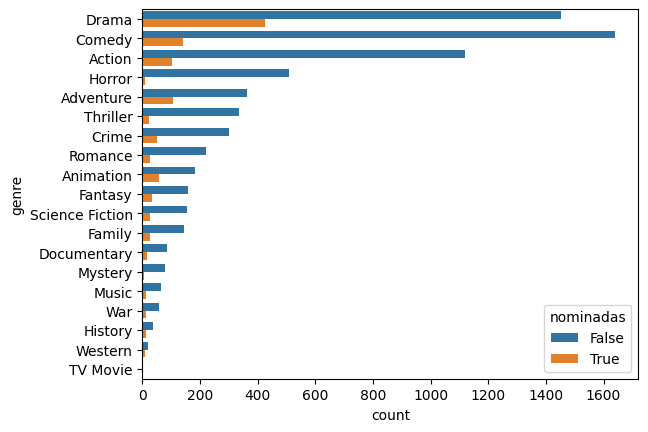

In [132]:
sns.countplot(data=pelis, y='genre', hue= 'nominadas', order=pelis['genre'].value_counts().index)

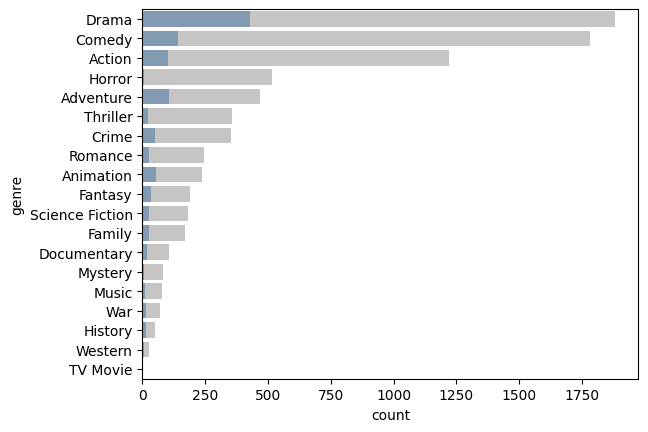

In [133]:
#Mirar aquí colores que contrasten bien pero no queden horribles
# # Azul suave para total, dorado para nominadas
# color_total = "#B0C4DE"      # azul acero claro
# color_nominadas = "#C9A84C"  # dorado

# # O una combinación más sobria
# color_total = "#D3D3D3"      # gris claro
# color_nominadas = "#4A7FB5"  # azul medio
sns.countplot(data=pelis, y='genre', order=pelis['genre'].value_counts().index, color="#C7C4C4")
sns.countplot(data=pelis[pelis['nominadas'] == True], y='genre', order=pelis['genre'].value_counts().index, color="#4A7FB5", alpha=0.6)
plt.show()

Next: añadir, porcentajes en texto, visualizar mejor si hay algun género más/menos nominado de media


In [134]:
nominaciones_genero = pelis.groupby ('genre').agg ({'nominadas': ('count','mean')})


In [135]:
nominaciones_genero

nominadas          
                    count      mean
genre                              
Action               1220  0.082787
Adventure             469  0.223881
Animation             239  0.234310
Comedy               1781  0.079730
Crime                 354  0.146893
Documentary           104  0.163462
Drama                1881  0.227007
Family                169  0.147929
Fantasy               191  0.172775
History                51  0.254902
Horror                518  0.015444
Music                  77  0.142857
Mystery                84  0.083333
Romance               247  0.113360
Science Fiction       180  0.144444
TV Movie                1  0.000000
Thriller              358  0.061453
War                    72  0.180556
Western                28  0.285714

In [136]:
#TV Movie es cero relevante como categoría
nominaciones_genero = nominaciones_genero.drop ('TV Movie', axis = 0 )

In [137]:
nominaciones_genero.columns = ['total','media']
nominaciones_genero ['media'] = (nominaciones_genero ['media']*100).round(1)


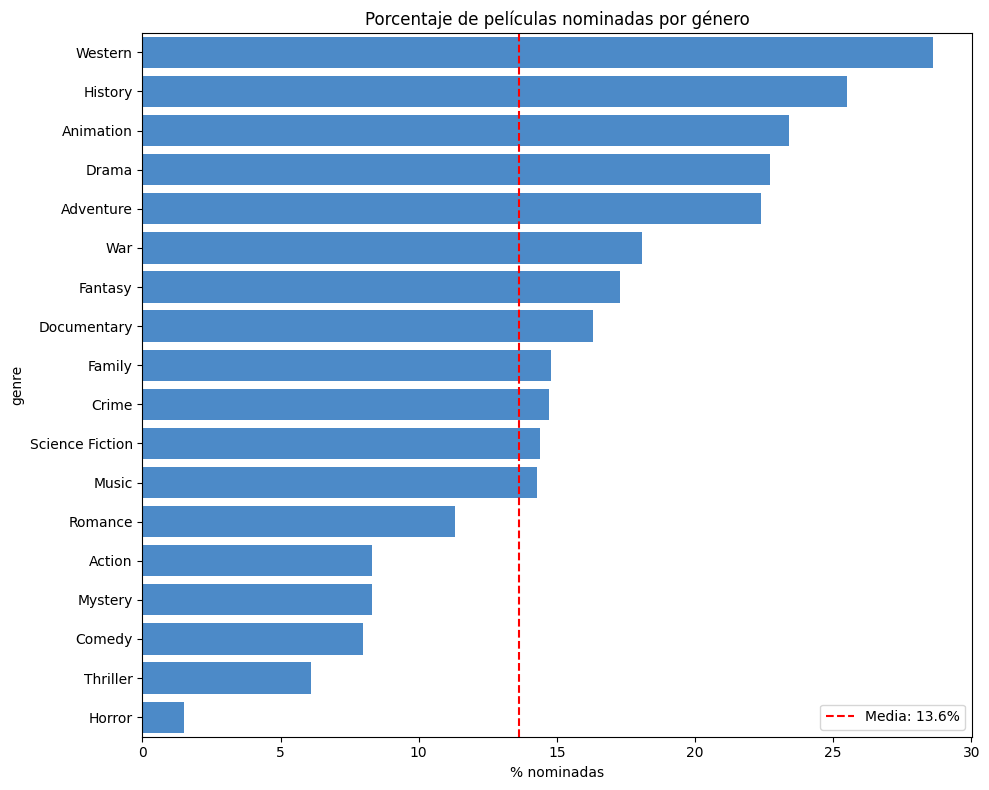

In [138]:
nominaciones_genero_orden= nominaciones_genero.sort_values('media', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=nominaciones_genero_orden, y=nominaciones_genero_orden.index, x='media', color="#378ADD")

media_general = pelis['nominadas'].mean() * 100
plt.axvline(media_general, color='red', linestyle='--', label=f'Media: {media_general:.1f}%')
plt.legend()
plt.xlabel('% nominadas')
plt.title('Porcentaje de películas nominadas por género')
plt.tight_layout()

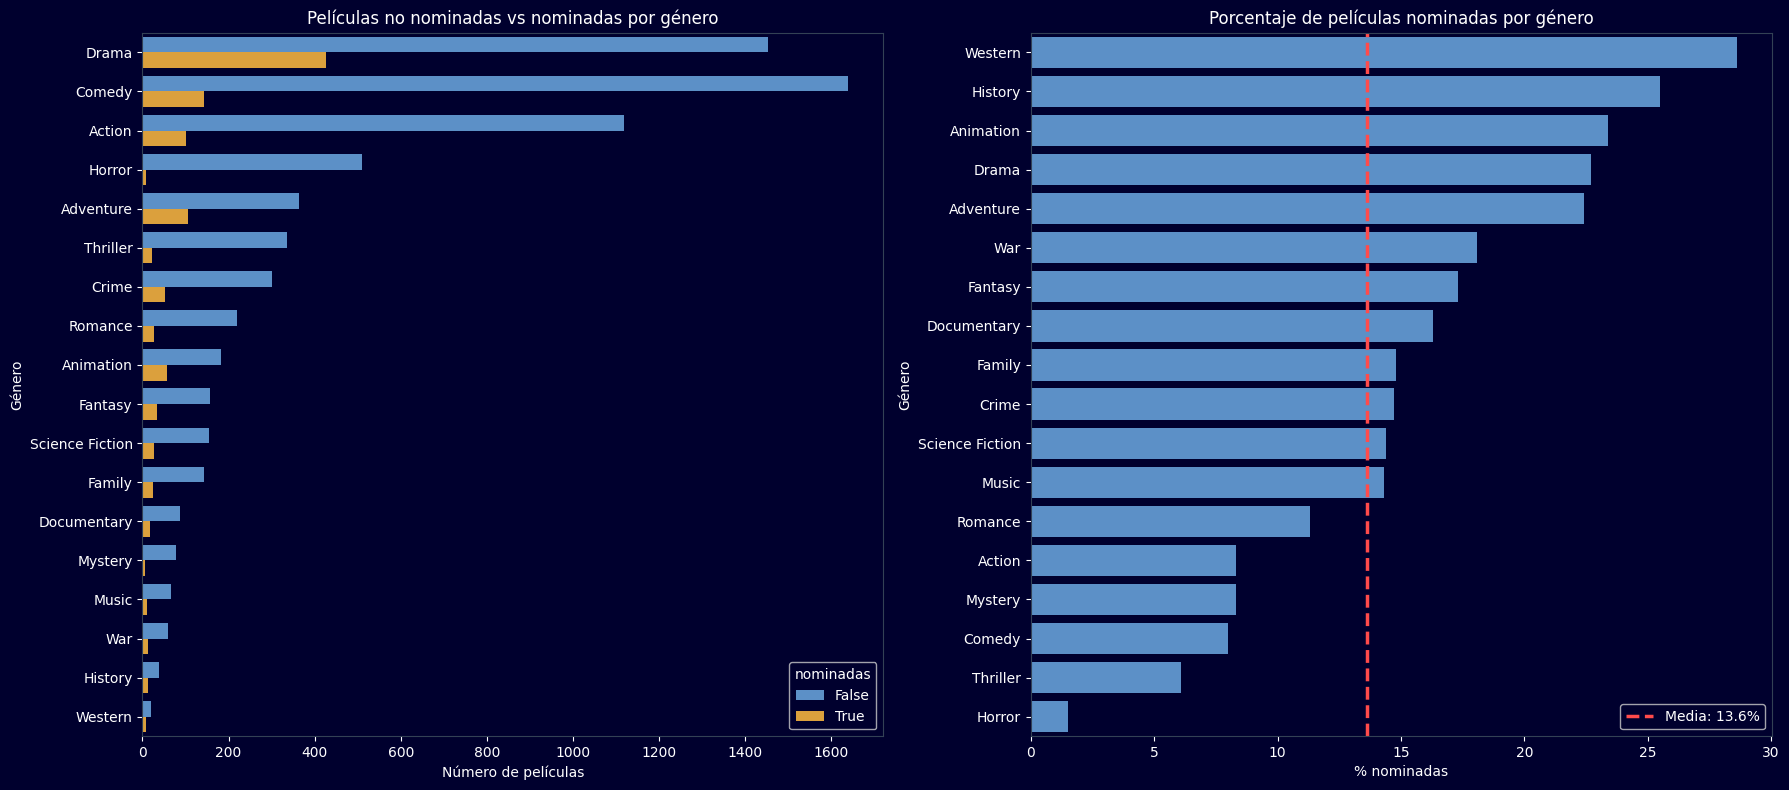

In [139]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8), facecolor='#00002e')

for ax in axes:
    ax.set_facecolor('#00002e')
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    plt.setp(ax.spines.values(), color='#334155')

# Gráfico 1: countplot con hue
orden = pelis[pelis['genre'] != 'TV Movie']['genre'].value_counts().index
sns.countplot(data=pelis[pelis['genre'] != 'TV Movie'], y='genre', hue='nominadas', order=orden,
              palette={False: '#4A90D9', True: '#F5A623'}, ax=axes[0])
axes[0].set_title('Películas no nominadas vs nominadas por género', color='white')
axes[0].set_xlabel('Número de películas', color='white')
axes[0].set_ylabel('Género', color='white')
legend = axes[0].get_legend()
legend.get_frame().set_facecolor('#00002e')
legend.get_title().set_color('white')
for text in legend.get_texts():
    text.set_color('white')

# Gráfico 2: barplot porcentaje nominadas
nominaciones_genero_orden = nominaciones_genero.sort_values('media', ascending=False)
sns.barplot(data=nominaciones_genero_orden, y=nominaciones_genero_orden.index,
            x='media', color='#4A90D9', ax=axes[1])
media_general = pelis['nominadas'].mean() * 100
axes[1].axvline(media_general, color='#FF4B4B', linestyle='--', linewidth=2.5,
                label=f'Media: {media_general:.1f}%')
axes[1].legend(labelcolor='white', facecolor='#00002e')
axes[1].set_xlabel('% nominadas', color='white')
axes[1].set_ylabel('Género', color='white')
axes[1].set_title('Porcentaje de películas nominadas por género', color='white')

plt.tight_layout()
plt.show()

Horror es el género más infra-nominado con solo un 1.5% a pesar de que hay muchas peliculas del género 
Wstern y History son los más sobre-nominados con un 25.5% aunque el número de películas es claramente más bajo.
Drama y Animation también tienen tasas altas (~23%) - Nos gusta un drama: tanto para hacer la peli como para nominarla
Action y Comedy a pesar de ser casi los géneros con más películas (solo por detrás de drama) tienen tasas bajas (~8%)

In [140]:
pelis ['count'] = order=pelis['genre'].value_counts()

ROI por género: ¿hay algún genero más rentable? ¿los Oscars tienen algo que ver con eso?


In [141]:
roi_genero = pelis.groupby('genre') ['ROI'].mean().round(1).sort_values (ascending=False)

In [142]:
roi_genero = roi_genero.drop ('TV Movie', axis=0)

In [143]:
roi_genero.reset_index()

,genre,ROI
0,Horror,16.6
1,Documentary,9.6
2,Music,5.3
3,Mystery,4.9
4,Romance,4.6
5,Drama,4.2
6,Comedy,4.2
7,Fantasy,3.7
8,Thriller,3.6
9,War,3.2


In [144]:
roi_genero = pelis.groupby('genre') ['revenue'].mean().round(1).sort_values (ascending=False)

In [146]:
roi_genero

genre
Adventure          195667527.4
Animation          177426456.3
Family             139638936.7
Fantasy            138090401.5
Science Fiction    128101569.8
Action             115013030.9
War                 69236224.5
Mystery             58927946.9
Thriller            51079557.2
Comedy              49557704.4
Western             49194570.4
Music               47944754.0
Crime               45468212.2
Horror              44091463.0
History             42411041.0
TV Movie            42000000.0
Romance             41856588.9
Drama               38760495.7
Documentary         11915174.6
Name: revenue, dtype: float64

In [147]:
roi_genero.info()

<class 'pandas.Series'>
Index: 19 entries, Adventure to Documentary
Series name: revenue
Non-Null Count  Dtype  
--------------  -----  
19 non-null     float64
dtypes: float64(1)
memory usage: 860.0+ bytes


Text(0, 0.5, 'género')

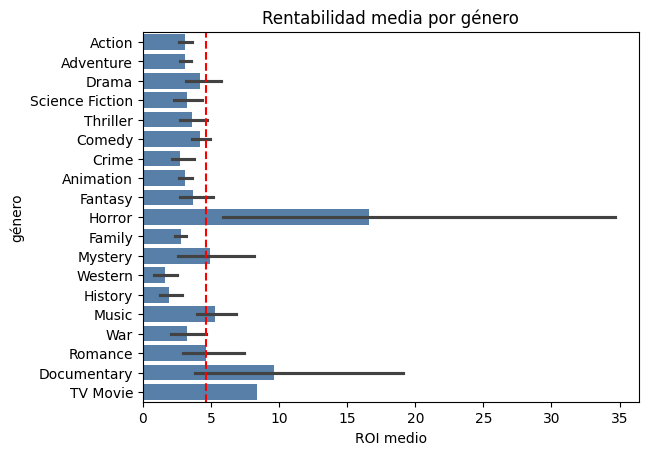

In [151]:
sns.barplot(data=pelis, y='genre', x='ROI', color="#4A7FB5")
plt.axvline(pelis['ROI'].mean(), color='red', linestyle='--', label='Media general')
plt.title('Rentabilidad media por género')
plt.xlabel('ROI medio')
plt.ylabel('género')

Hay cosas interesantes! Justo en contrapartida al tema de nominaciones aquí resulta que de media las películas de terror son por género las más rentables.
Pero es cierto que la incertidumbre tanto en Terror como en Documental que son las que presentan datos más llamativos es mayor (intervalos muy amplios). En el caso del Documental se ve claro que es por un número bajo de datos y en Horror puesto que sí hay suficientes datos es de suponer que habrá mucha dispersión en los datos. Igual un pelotazo

In [ ]:
genero_rentabilidad = pelis.groupby('genre').aggregate ({'ROI': ('mean', 'median'),
                                                'budget':'mean'})
genero_rentabilidad.columns = ['Media ROI','Mediana ROI', 'Media presupuesto']

In [ ]:
genero_rentabilidad ['Media ROI'] = genero_rentabilidad ['Media ROI'].round(1)
genero_rentabilidad ['Media presupuesto'] = genero_rentabilidad ['Media presupuesto']/1000000

In [ ]:
genero_rentabilidad.rename ({'Media presupuesto' : 'Media presupuesto (mill $)'}, inplace=True)

In [ ]:

genero_rentabilidad = genero_rentabilidad.drop('TV Movie', axis=0)
genero_rentabilidad.sort_values (by="Media ROI",ascending=False)

,Media ROI,Mediana ROI,Media presupuesto
genre,,,
Horror,16.6,2.506978,12.109591
Documentary,9.6,1.807859,2.725240
Music,5.3,2.933333,13.963933
Mystery,4.9,1.252990,22.282465
Romance,4.6,1.946844,14.610851
Comedy,4.2,1.904883,18.127339
Drama,4.2,1.288132,16.345767
Fantasy,3.7,1.954816,47.693850
Thriller,3.6,1.419102,22.378052


Géneros de alto presupuesto y ROI moderado (Action, Adventure, Animation, Science Fiction): necesitan mucha inversión para competir, el margen es menor aunque recaudan mucho en términos absolutos.
Géneros de bajo presupuesto y alto ROI (Horror, Documentary): riesgo financiero menor y aparentemente más fiables en cuanto a rentabilidad 
Géneros equilibrados (Comedy, Drama): presupuesto medio y ROI decente, puede entenderse por qué son el grueso de la industria.

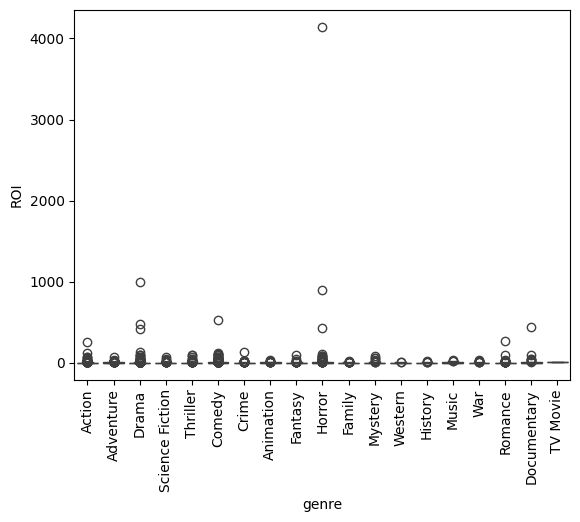

In [ ]:
# Entender cuánto de relevantes son estos datos. Es extensible al género o hay unas cuantas películas 
# que han dado un bombazo y por eso los datos salen así? 

sns.boxplot (data=pelis, y='ROI', x='genre')
plt.xticks (rotation=90);

Hay unos outliers claros en algunas categorías. CUales son?

In [ ]:
pelis[pelis['genre'] == 'Horror'].sort_values('revenue', ascending=False)[['title', 'revenue','year']].head(5)

,title,revenue,year
59,It,701800000,2017.0
370,It Chapter Two,473122525,2019.0
577,The Nun,365582797,2018.0
151,A Quiet Place,341000000,2018.0
389,The Conjuring 2,321834351,2016.0


In [ ]:
pelis[pelis['genre'] == 'Drama'].sort_values('revenue', ascending=False)[['title', 'revenue','year']].head(5)

,title,revenue,year
17,Titanic,2264162353,1997.0
2,The Dark Knight,1004558444,2008.0
52,The Martian,630600000,2015.0
946,The Passion of the Christ,611899420,2004.0
112,I Am Legend,585410052,2007.0


In [ ]:
pelis[pelis['genre'] == 'Comedy'].sort_values('revenue', ascending=False)[['title', 'revenue','year']].head(5)

,title,revenue,year
480,Shrek Forever After,752600867,2010.0
10,Forrest Gump,677387716,1994.0
585,Mamma Mia!,609841637,2008.0
276,The Hangover Part II,586764305,2011.0
4543,The Mermaid,553810228,2016.0


In [ ]:
pelis[pelis['genre'] == 'Action'].sort_values('revenue', ascending=False)[['title', 'revenue','year']].head(5)

,title,revenue,year
3,Avatar,2923706026,2009.0
44,Jurassic World,1671537444,2015.0
262,Furious 7,1515341399,2015.0
23,Avengers: Age of Ultron,1405403694,2015.0
27,Black Panther,1349926083,2018.0


In [ ]:
pelis[pelis['genre'] == 'Romance'].sort_values('revenue', ascending=False)[['title', 'revenue','year']].head(5)

,title,revenue,year
494,Cinderella,543514353,2015.0
305,Beauty and the Beast,424967620,1991.0
822,There's Something About Mary,369884651,1998.0
661,Notting Hill,363889678,1999.0
396,Top Gun,356830601,1986.0


In [ ]:
pelis[pelis['genre'] == 'Documentary'].sort_values('revenue', ascending=False)[['title', 'revenue','year']].head(5)

,title,revenue,year
2516,Fahrenheit 9/11,222446882,2004.0
2930,March of the Penguins,127392693,2005.0
4656,Earth,109000000,2007.0
6252,Hannah Montana & Miley Cyrus: Best of Both Wor...,70642966,2008.0
2992,One Direction: This Is Us,68500000,2013.0


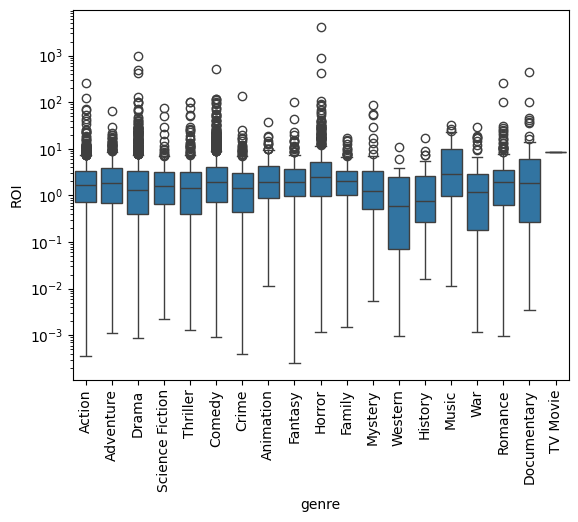

In [ ]:
#He aplicado log porque salía aplanadísimo.
sns.boxplot (data=pelis, y='ROI', x='genre')
plt.xticks (rotation=90)
plt.yscale ('log');

Ojo. Aplanando los outliers, las diferencias entre géneros ya no parecen tan grandes. Las medias están muy influenciadas por ejemplos concretos

Text(0.5, 0, 'ROI medio')

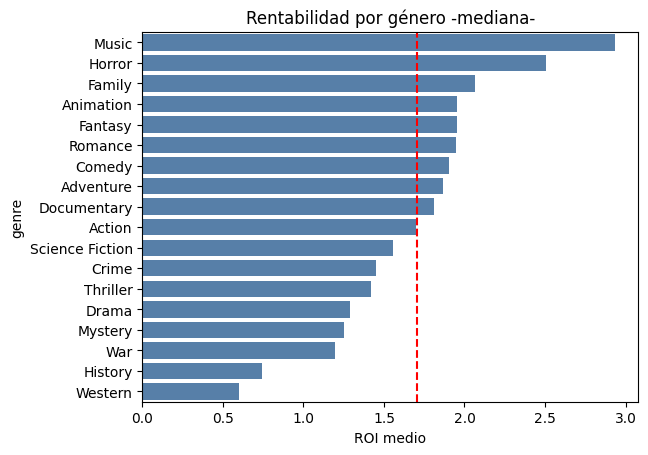

In [ ]:
sns.barplot(data=genero_rentabilidad, y='genre', x='Mediana ROI', order=genero_rentabilidad.sort_values('Mediana ROI',ascending=False).index, color="#4A7FB5")
plt.axvline(pelis['ROI'].median(), color='red', linestyle='--', label='Media general')
plt.title('Rentabilidad por género -mediana-')
plt.xlabel('ROI medio')

<Axes: xlabel='ROI', ylabel='genre'>

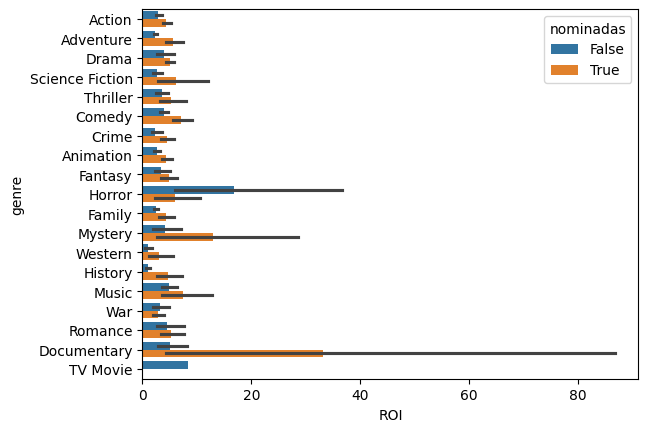

In [ ]:
#Por ligarlo un poco con el tema de nominaciones vamos a ver si hay algo interesante  comparando ROI de nominadas
#  vs no nominadas
sns.barplot(data=pelis, y='genre', x='ROI', hue='nominadas')

El patrón general:
En la mayoría de géneros las nominadas tienen ROI similar o ligeramente superior a las no nominadas, pero hay excepciones claras como Documentary y Mystery donde las nominaciones marca una diferencia enorme. 

Las nominaciones a los Oscars no parece garantizan rentabilidad en la mayoría de géneros, con la excepción de Documentary y Mystery.
Pero al ser categorías con muy pocas películas, es probable que haya una o dos pelis excepcionales que estén alterando la visión

En Terror se da el caso contrario. También la incertidumbre es muy alta.

In [158]:
# Pelis con ROI más alto de terror y que no estén nominadas
terror = pelis [(pelis['genre'] == 'Horror') & (pelis['nominadas']==False)]
terror [['title', 'ROI']].sort_values ('ROI', ascending = False).head(15)


,title,ROI
857,The Blair Witch Project,4143.984983
797,Paranormal Activity,899.329302
3198,The Gallows,429.644100
1485,Friday the 13th,108.644729
3728,The Quiet Ones,89.174335
351,Saw,86.593058
1082,The Evil Dead,84.606763
540,Insidious,66.580591
1228,Unfriended,62.882090
1647,Paranormal Activity 2,59.170677


Hay varias películas con retornos altísimos. 

In [ ]:
#Qué peliculas están nominadas en las categorías Documentary y Mystery y cual es su ROI
doc_mystery = pelis [((pelis['genre'] == 'Mystery' )| (pelis['genre'] == 'Documentary')) & (pelis['nominadas']==True)]

In [ ]:
doc_mystery [['title','genre','ROI','nominees']].sort_values ('ROI', ascending=False).head(15)

,title,genre,ROI,nominees
2254,Super Size Me,Documentary,439.616585,1.0
87,Get Out,Mystery,56.757326,4.0
3344,An Inconvenient Truth,Documentary,46.243000,2.0
226,The Sixth Sense,Mystery,16.820157,6.0
2930,March of the Penguins,Documentary,15.924087,1.0
4905,Hoop Dreams,Documentary,11.186587,1.0
5349,Born Into Brothels: Calcutta's Red Light Kids,Documentary,10.083431,1.0
2385,Bowling for Columbine,Documentary,8.891118,1.0
4261,I Am Not Your Negro,Documentary,7.123919,1.0
67,Gone Girl,Mystery,6.054596,1.0


In [ ]:
# Merece la pena hacer un análisis de los títulos que lo petaron? Hay suficientes?
pelis[pelis['awards'] >= 3][['title', 'awards', 'nominees']].sort_values('awards', ascending=False)

,title,awards,nominees
20,The Lord of the Rings: The Return of the King,11.0,11.0
17,Titanic,11.0,14.0
2279,The Last Emperor,9.0,9.0
1868,The English Patient,9.0,12.0
993,Amadeus,8.0,11.0
...,...,...,...
3607,A Room with a View,3.0,8.0
3629,The Killing Fields,3.0,7.0
4160,Howards End,3.0,9.0
4329,On Golden Pond,3.0,10.0


In [ ]:
# Merece la pena hacer un análisis de los títulos que lo petaron? Hay suficientes?
pelis[pelis['awards'] >= 5][['title', 'awards', 'nominees']].sort_values('awards', ascending=False)

,title,awards,nominees
17,Titanic,11.0,14.0
20,The Lord of the Rings: The Return of the King,11.0,11.0
1868,The English Patient,9.0,12.0
2279,The Last Emperor,9.0,9.0
266,Slumdog Millionaire,8.0,10.0
993,Amadeus,8.0,11.0
1741,Gandhi,8.0,11.0
116,Schindler's List,7.0,12.0
994,Dances with Wolves,7.0,12.0
1372,Shakespeare in Love,7.0,13.0


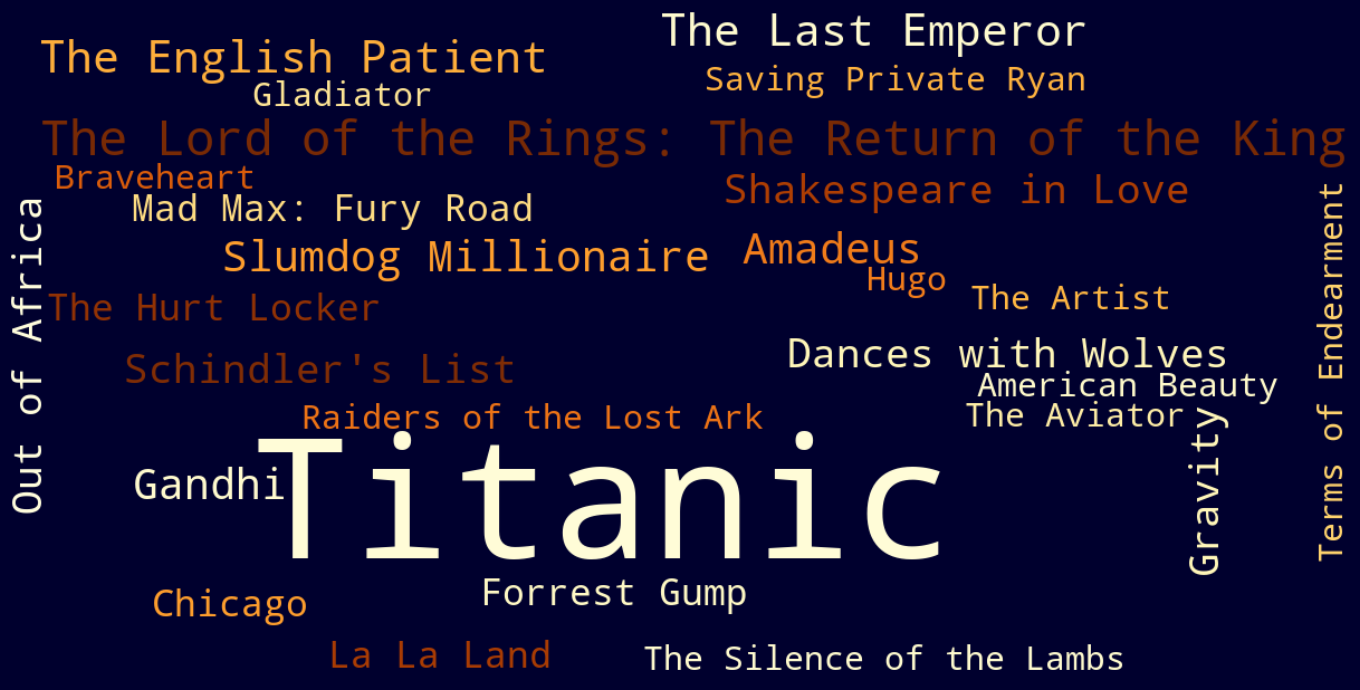

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Crear diccionario {título: número de premios}
frecuencias = dict(zip(
    pelis[pelis['awards'] >= 5]['title'],
    pelis[pelis['awards'] >= 5]['awards'].astype(int)
))

# Crear wordcloud
wc = WordCloud(
    background_color='#00002e',
    width=1200,
    height=600,
    colormap='YlOrBr',
    max_font_size=150,
    min_font_size=20,
    prefer_horizontal=0.9
).generate_from_frequencies(frecuencias)

fig, ax = plt.subplots(figsize=(14, 7), facecolor='#00002e')
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')


plt.tight_layout()
plt.show()

In [ ]:
# Vamos a ver si hay diferencias significativas o cosas en común entre los grandes triunfadores
big_ones = pelis [pelis["awards"] >= 3]
rest = pelis [pelis["awards"] < 3]

In [ ]:
big_ones [['budget', 'revenue', 'ROI', 'averageRating']].describe()


,budget,revenue,ROI,averageRating
count,9.000000e+01,9.000000e+01,90.000000,90.000000
mean,5.065403e+07,3.426442e+08,9.158546,78.933333
std,5.413502e+07,4.340673e+08,9.406289,5.049864
min,3.000000e+06,1.140769e+06,0.076051,62.000000
25%,1.500000e+07,9.961132e+07,3.636751,75.000000
50%,2.500000e+07,2.208420e+08,6.841174,79.000000
75%,7.000000e+07,4.217095e+08,12.212874,82.000000
max,2.370000e+08,2.923706e+09,75.520524,90.000000


In [ ]:
rest [['budget', 'revenue', 'ROI', 'averageRating']].describe()

,budget,revenue,ROI,averageRating
count,7.934000e+03,7.934000e+03,7934.000000,7934.000000
mean,2.607564e+07,7.106916e+07,4.586408,62.908621
std,3.755964e+07,1.538012e+08,50.935673,10.910744
min,1.000000e+04,5.000000e+03,0.000256,11.000000
25%,4.000000e+06,2.775671e+06,0.589957,57.000000
50%,1.245447e+07,1.688634e+07,1.673495,64.000000
75%,3.000000e+07,6.791399e+07,3.558498,70.000000
max,3.790000e+08,2.800000e+09,4143.984983,95.000000


En todos los valores parece que hay diferencias notables:
- Big ones tienen de media el doble de presupuesto
- Pero también recaudan más: casi 5 veces más
- Son casi el doble de rentables
- Mucho mejor valoradas. Esto ya lo habíamos visto

C:\Users\NaiaJon\AppData\Local\Temp\ipykernel_18116\1840232997.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Resto', 'Grandes ganadores'], y=valores, palette=colores, ax=ax)
C:\Users\NaiaJon\AppData\Local\Temp\ipykernel_18116\1840232997.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Resto', 'Grandes ganadores'], y=valores, palette=colores, ax=ax)
C:\Users\NaiaJon\AppData\Local\Temp\ipykernel_18116\1840232997.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Resto', 'Grandes ganadores'], y=valores, palette=colores, ax

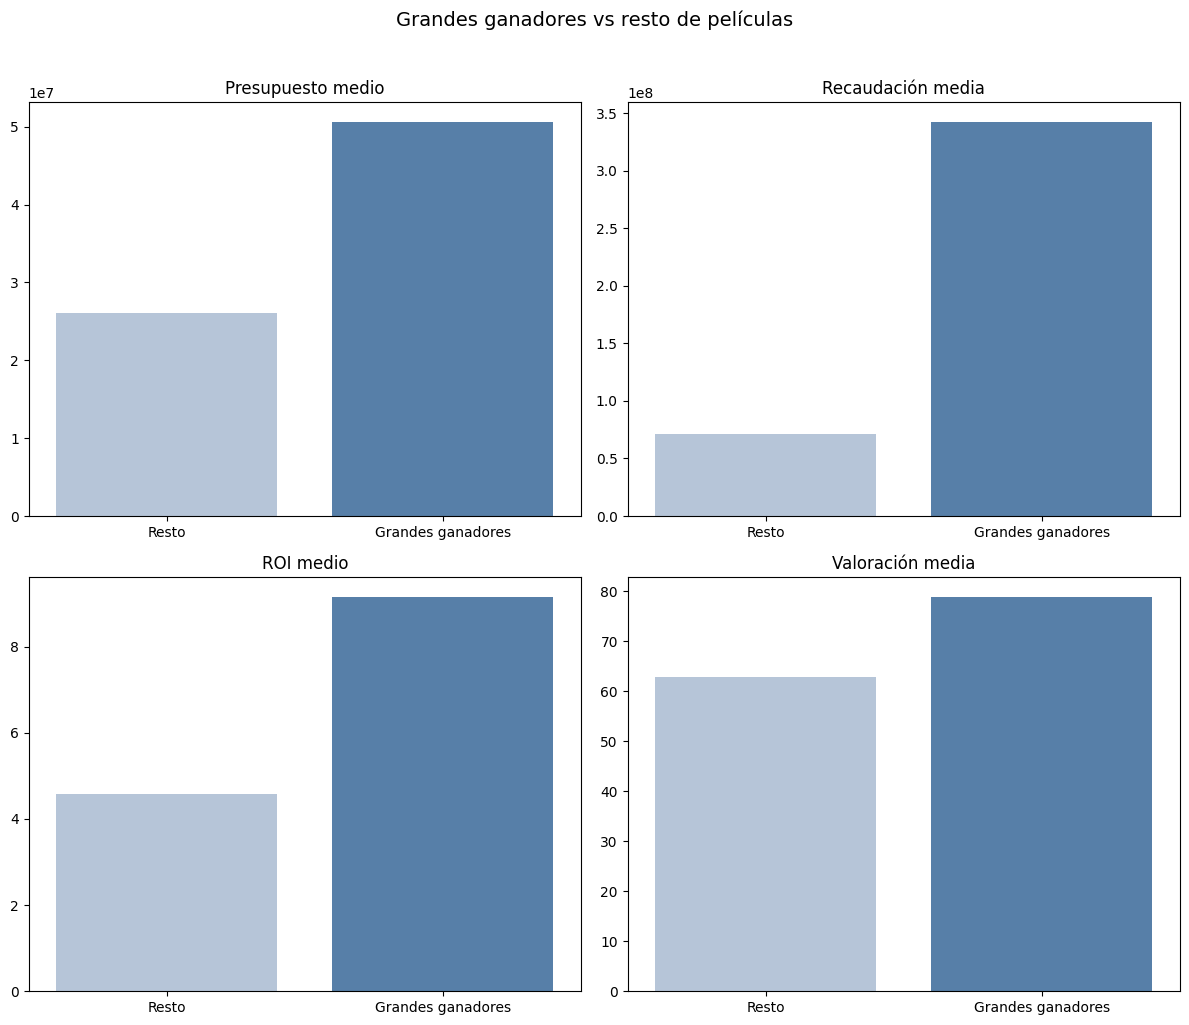

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

metricas = ['budget', 'revenue', 'ROI', 'averageRating']
titulos = ['Presupuesto medio', 'Recaudación media', 'ROI medio', 'Valoración media']
colores = ['#B0C4DE', '#4A7FB5']

for ax, metrica, titulo in zip(axes.flatten(), metricas, titulos):
    valores = [rest[metrica].mean(), big_ones[metrica].mean()]
    sns.barplot(x=['Resto', 'Grandes ganadores'], y=valores, palette=colores, ax=ax)
    ax.set_title(titulo)
    ax.set_xlabel('')

plt.suptitle('Grandes ganadores vs resto de películas', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

metricas = ['budget', 'revenue', 'ROI', 'averageRating']
titulos = ['Presupuesto medio', 'Recaudación media', 'ROI medio', 'Valoración media']

fig = make_subplots(rows=2, cols=2, subplot_titles=titulos)

posiciones = [(1,1), (1,2), (2,1), (2,2)]

for (row, col), metrica in zip(posiciones, metricas):
    
    fig.add_trace(go.Bar(
        x=['Resto', 'Grandes ganadores'],
        y=[rest[metrica].mean(), big_ones[metrica].mean()],
        marker_color=['#B0C4DE', '#4A7FB5'],
        showlegend=False
    ), row=row, col=col)

fig.update_layout(
    title=dict(text='Grandes ganadores vs resto de películas', font=dict(size=16)),
    height=600,
    width=900,
    template='plotly_white',
    font=dict(family='Arial')
)

fig.show()

In [ ]:
rest['budget_M'] = rest['budget'] / 1e6
rest['revenue_M'] = rest['revenue'] / 1e6
big_ones ['budget_M'] = big_ones ['budget']/ 1e6
big_ones['revenue_M'] = big_ones ['revenue'] / 1e6

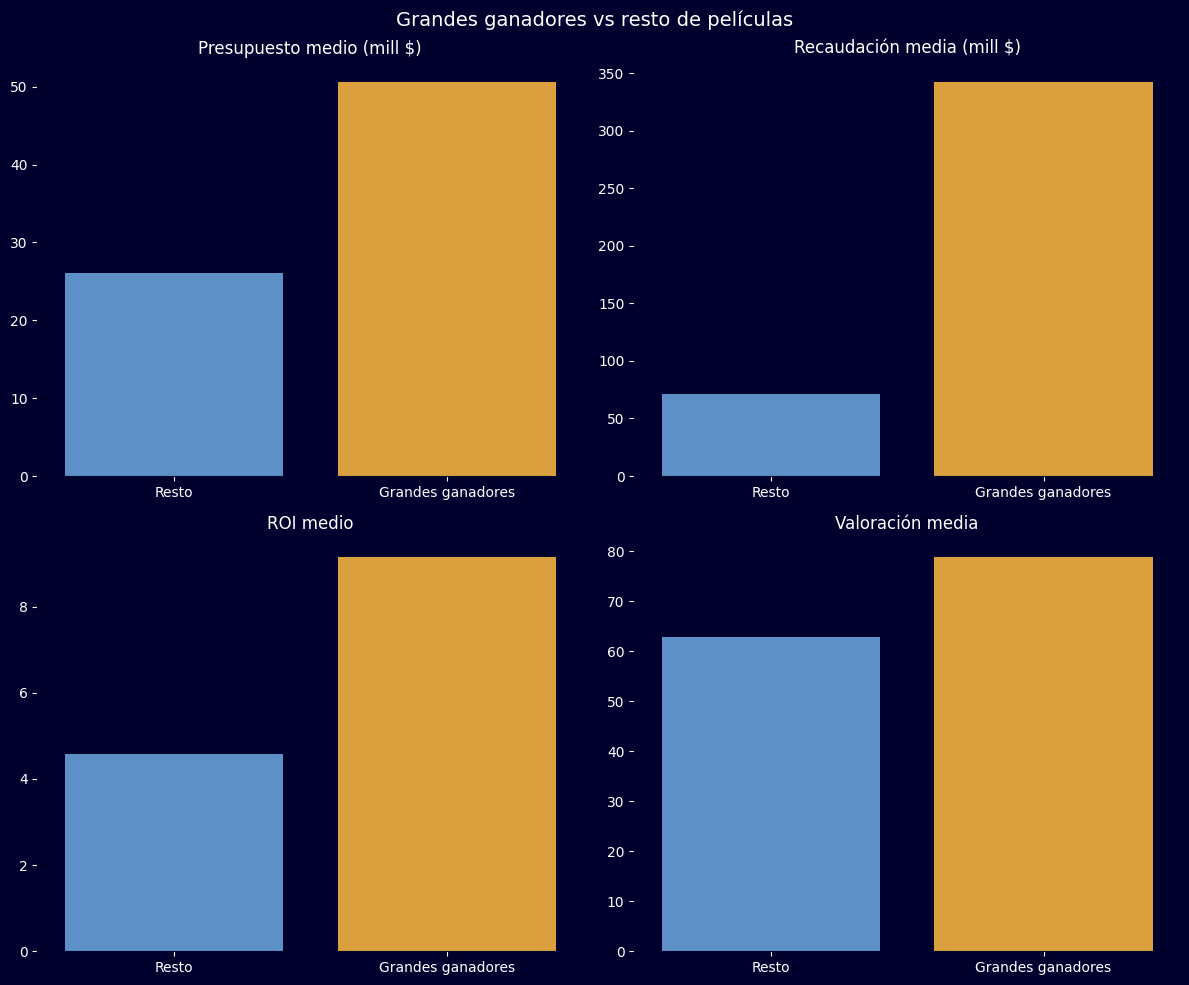

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10), facecolor='#00002e')

metricas = ['budget_M', 'revenue_M', 'ROI', 'averageRating']
titulos = ['Presupuesto medio (mill $)', 'Recaudación media (mill $)', 'ROI medio', 'Valoración media']
colores = ['#4A90D9', '#F5A623']

for ax, metrica, titulo in zip(axes.flatten(), metricas, titulos):
    valores = [rest[metrica].mean(), big_ones[metrica].mean()]
    grupos = ['Resto', 'Grandes ganadores']
    ax.set_facecolor('#00002e')
    sns.barplot(x=grupos, y=valores, hue=grupos, palette=colores, 
                legend=False, ax=ax)
    ax.set_title(titulo, color='white')
    ax.set_xlabel('')
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    plt.setp(ax.spines.values(), color='#00002e')

plt.suptitle('Grandes ganadores vs resto de películas', 
             fontsize=14, color='white')
plt.tight_layout()
plt.show()

In [ ]:
#Géneros?
big_ones['genre'].value_counts(normalize=True)*100

genre
Drama              50.000000
Adventure          11.111111
Action             10.000000
Comedy              8.888889
Fantasy             3.333333
History             3.333333
Western             2.222222
War                 2.222222
Crime               2.222222
Science Fiction     2.222222
Romance             2.222222
Music               1.111111
Thriller            1.111111
Name: proportion, dtype: float64

In [ ]:
#Es la misma proporción que en el resto?
rest['genre'].value_counts (normalize=True)*100


genre
Drama              23.140913
Comedy             22.346862
Action             15.263423
Horror              6.528863
Adventure           5.785228
Thriller            4.499622
Crime               4.436602
Romance             3.087976
Animation           3.012352
Fantasy             2.369549
Science Fiction     2.243509
Family              2.130073
Documentary         1.310814
Mystery             1.058735
Music               0.957903
War                 0.882279
History             0.604991
Western             0.327704
TV Movie            0.012604
Name: proportion, dtype: float64

Text(0, 0.5, 'Género')

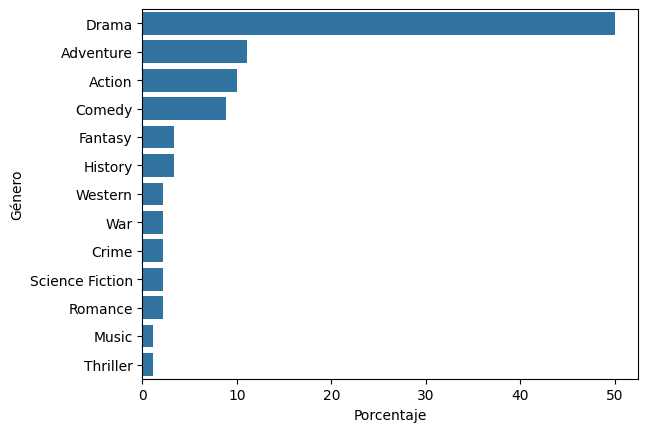

In [ ]:
genre_pct = big_ones['genre'].value_counts(normalize=True).mul(100).reset_index()
genre_pct.columns = ['genre', 'pct']
sns.barplot(data=genre_pct, x='pct', y='genre')
plt.xlabel ('Porcentaje')
plt.ylabel ('Género')


Text(0, 0.5, 'Género')

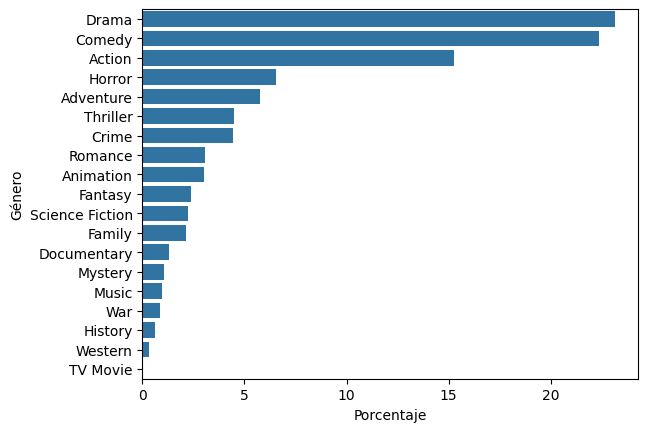

In [ ]:
genre_pct = rest['genre'].value_counts(normalize=True).mul(100).reset_index()
genre_pct.columns = ['genre', 'pct']
sns.barplot(data=genre_pct, x='pct', y='genre')
plt.xlabel ('Porcentaje')
plt.ylabel ('Género')

In [ ]:
# Drama domina de forma muy aplastante: 50% vs 23% en el resto. Una de cada dos películas con 3+ Oscars es un drama.
# Horror casi desaparece: 6.5% en el resto pero ni aparece entre los grandes ganadores.Lo habíamos visto ya. No se premia
# Comedy cae a la mitad: 22% del resto vs 9% entre grandes ganadores. Las comedias no ganan Oscars.